In [ ]:
# importing the required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:

# data ingestion and date column preprocessing

# data ingestion
# df = pd.read_csv("/content/drive/MyDrive/epex_fr_temp_train.csv")

df = pd.read_csv("/content/epex_fr_temp_train.csv")
df

In [ ]:
# conversion of date column to datetime object
df['Date'] = pd.to_datetime(df['Date'] , format='%Y-%m-%d')

df.sort_values(by = 'Date' , inplace = True)
df.head()

In [ ]:
# # seperate the training data from holdout
# df_pred = df[df['Date'] >= '2020-07-01']
# df_pred.to_csv("/content/drive/MyDrive/epex_fr_temp_pred.csv", index = False)
# df_train = df[df['Date'] < '2020-07-01']
# df_train.to_csv("/content/drive/MyDrive/epex_fr_temp_train.csv", index = False)

In [ ]:
df.describe()

,Date,NUCLEAR AVAIL. (MW),DEMAND (MW),PRICE (EUR/MWH),PARIS_AVGTEMP_C,LYON_AVGTEMP_C,BORDEAUX_AVGTEMP_C,MARSEILLE_AVGTEMP_C
count,2007,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000,2007.000000
mean,2017-10-01 00:00:00,46149.549576,53698.203288,40.292975,12.469008,13.591729,14.244993,16.161435
min,2015-01-02 00:00:00,27704.000000,35560.000000,-10.000000,-4.500000,-5.200000,-3.000000,-0.200000
25%,2016-05-17 12:00:00,41355.000000,45998.500000,30.000000,7.400000,7.700000,9.800000,10.800000
50%,2017-10-01 00:00:00,45370.000000,50321.000000,38.000000,12.000000,13.200000,13.800000,15.700000
75%,2019-02-14 12:00:00,50669.500000,61804.000000,48.000000,17.500000,19.500000,19.000000,21.800000
max,2020-06-30 00:00:00,61778.000000,88425.000000,126.000000,33.200000,32.300000,31.800000,31.600000
std,NaN,6249.854950,10696.797849,15.859455,6.653834,7.516729,6.118397,6.813977


In [ ]:
df.info()

In [ ]:
# search for chronological gaps

df['diff'] = df['Date'].diff()
gaps_df = df[df['diff'] > pd.Timedelta(days = 1)]
df = df.drop(columns = ['diff'])
gaps_df.shape

if gaps_df.empty:
  print('no gaps were found')

In [ ]:
# setting date as the index
df.set_index('Date' , inplace = True)


check the region where these counts are missing

In [ ]:
# data cleaning

print(f"existing missing values per column before interpolation \n{df.isnull().sum()}")
# data interpolation for missing values
df = df.interpolate(method = 'time')
print(f"existing missing values per column after interpolation \n{df.isnull().sum()}")

# duplicates check
print(f"duplicated date count {df.index.duplicated().sum()}")

think about what other data cleaning processes might be required here

In [ ]:
# spot price transformation

df_trans = df.copy()
df_trans['PRICE (EUR/MWH)'] = np.arcsinh(df_trans['PRICE (EUR/MWH)'])



fig , axes = plt.subplots(2 , 1 , figsize = (14 , 10) , sharex = True )

# plot price over time
axes[0].plot(df_trans.index , df_trans['PRICE (EUR/MWH)'])
axes[0].set_title('Daily Electricity Spot Price (EUR/MWh)')
axes[0].set_ylabel('EUR/MWh')


axes[1].plot(df_trans.index , df_trans['NUCLEAR AVAIL. (MW)'])
axes[1].set_title('Daily Nuclear Availibility')

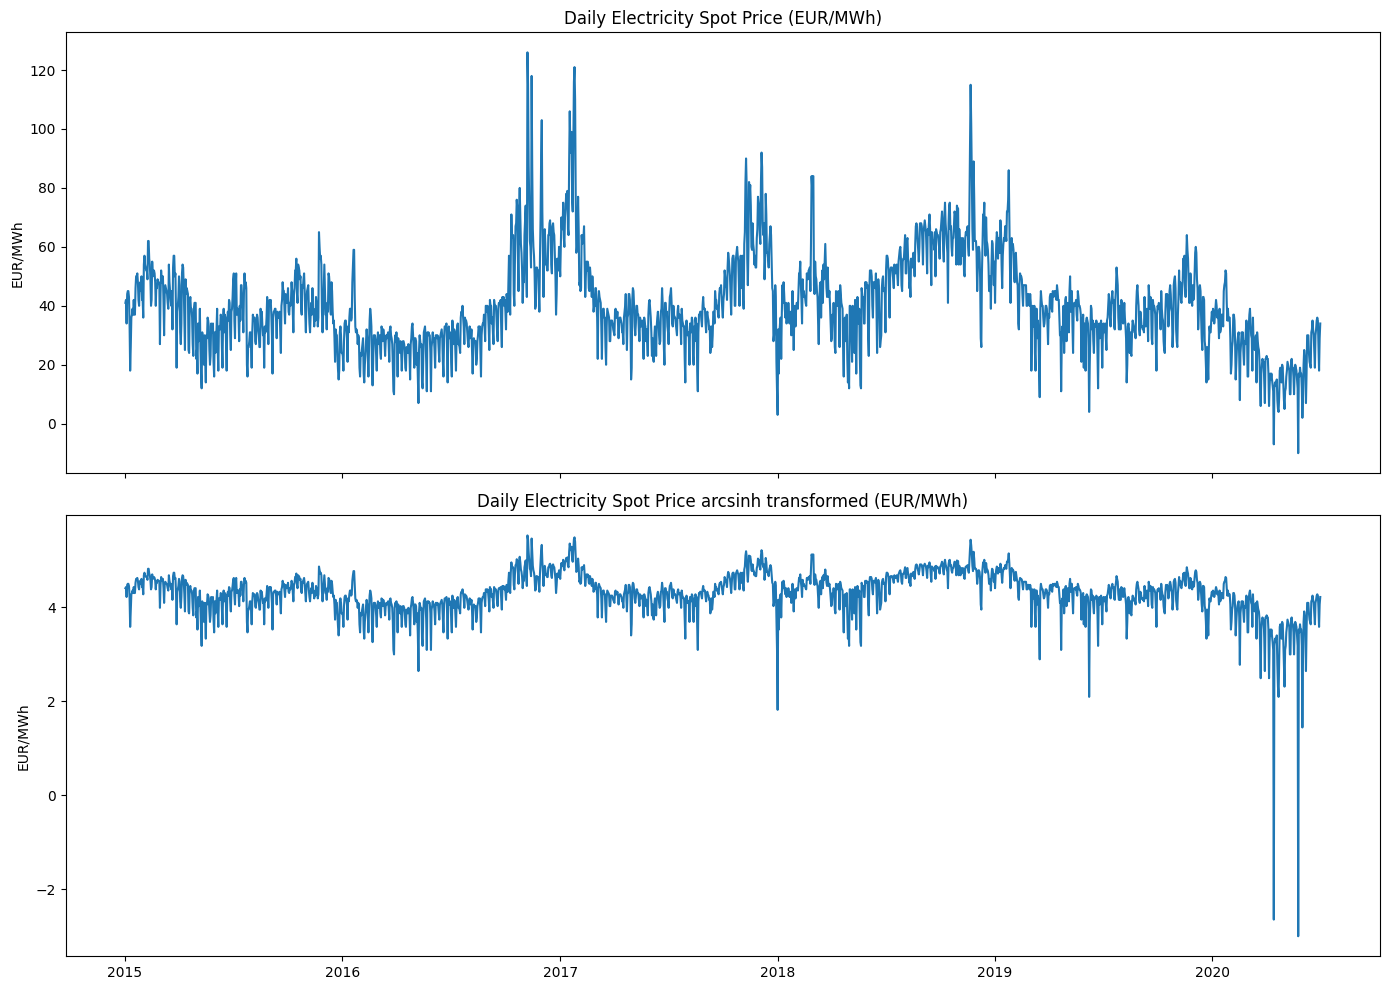

In [ ]:
fig , axes = plt.subplots(2 , 1 , figsize = (14 , 10) , sharex = True )

# plot price over time
axes[0].plot(df.index , df['PRICE (EUR/MWH)'])
axes[0].set_title('Daily Electricity Spot Price (EUR/MWh)')
axes[0].set_ylabel('EUR/MWh')


# axes[1].plot(df.index , df['NUCLEAR AVAIL. (MW)'])
# axes[1].set_title('Daily Nuclear Availibility')

axes[1].plot(df_trans.index , df_trans['PRICE (EUR/MWH)'])
axes[1].set_title('Daily Electricity Spot Price arcsinh transformed (EUR/MWh)')
axes[1].set_ylabel('EUR/MWh')

plt.tight_layout()

Text(0.5, 1.0, 'Correlation Heatmap')

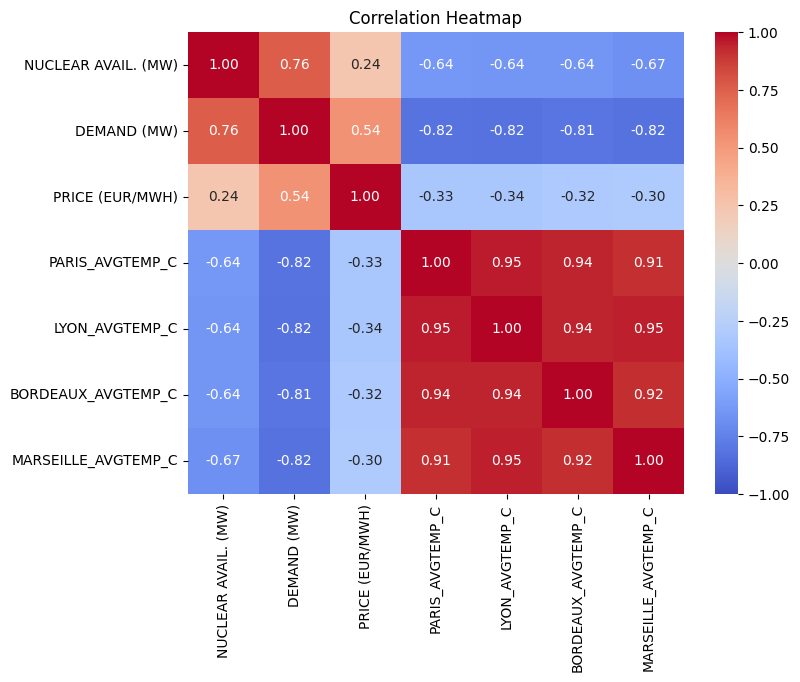

In [ ]:
# correlation_matrix

plt.figure(figsize=(8,6))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix , annot = True , cmap='coolwarm' , fmt="0.2f" , vmin = -1 , vmax = 1)
plt.title('Correlation Heatmap')

<Axes: xlabel='avg_temp', ylabel='DEMAND (MW)'>

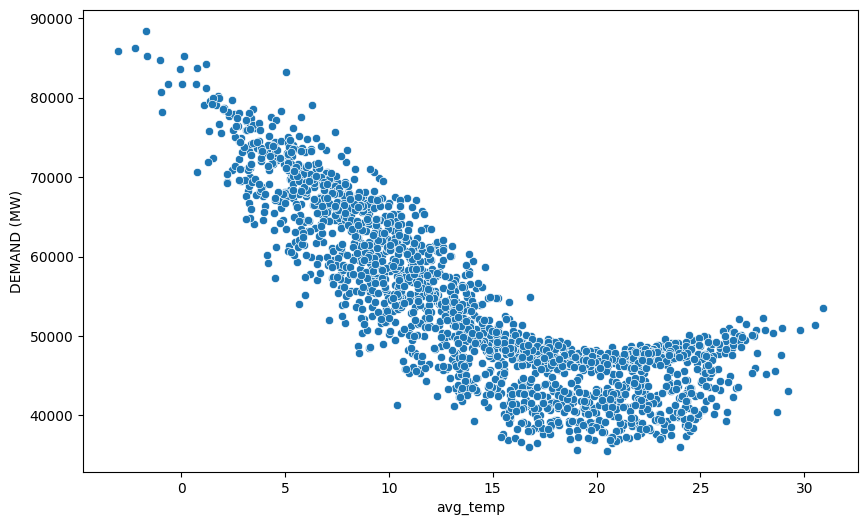

In [ ]:
# High correlation between the temperature features -> need to make a combined unweighted averaged climatology temperature.

df['avg_temp'] = (df['PARIS_AVGTEMP_C'] + df['LYON_AVGTEMP_C'] + df['BORDEAUX_AVGTEMP_C'] + df['MARSEILLE_AVGTEMP_C']) / 4
plt.figure(figsize = (10,6))
sns.scatterplot(x = 'avg_temp' , y = 'DEMAND (MW)', data = df)

<Axes: xlabel='PARIS_AVGTEMP_C', ylabel='PRICE (EUR/MWH)'>

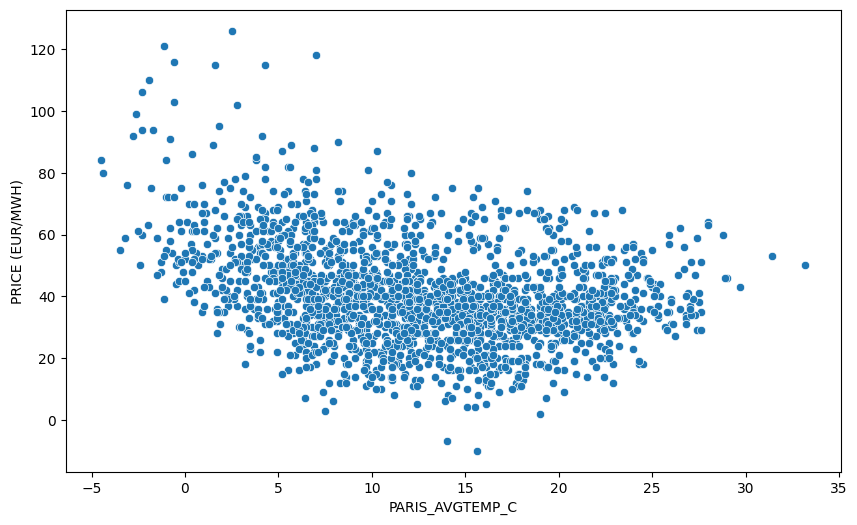

In [ ]:
plt.figure(figsize = (10,6))
sns.scatterplot(x = 'PARIS_AVGTEMP_C' , y = 'PRICE (EUR/MWH)' , data = df)

<Axes: xlabel='PARIS_AVGTEMP_C', ylabel='DEMAND (MW)'>

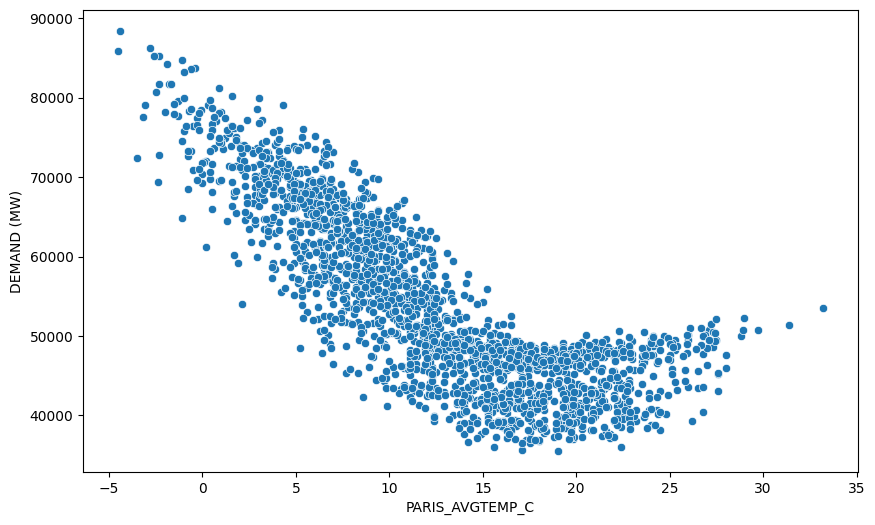

In [ ]:
plt.figure(figsize = (10,6))
sns.scatterplot(x = 'PARIS_AVGTEMP_C' , y = 'DEMAND (MW)' , data = df)

<Axes: xlabel='LYON_AVGTEMP_C', ylabel='DEMAND (MW)'>

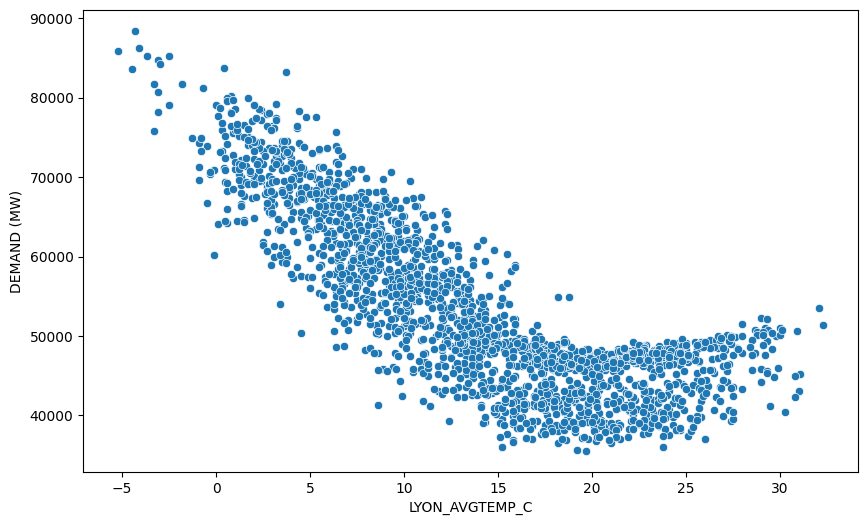

In [ ]:
plt.figure(figsize = (10,6))
sns.scatterplot(x = 'LYON_AVGTEMP_C' , y = 'DEMAND (MW)' , data = df)

<Axes: xlabel='BORDEAUX_AVGTEMP_C', ylabel='DEMAND (MW)'>

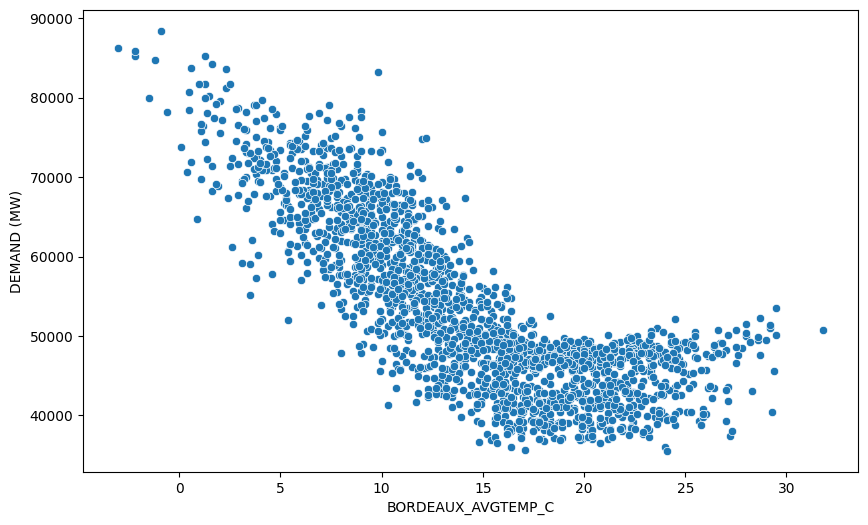

In [ ]:
plt.figure(figsize = (10,6))
sns.scatterplot(x = 'BORDEAUX_AVGTEMP_C' , y = 'DEMAND (MW)' , data = df)

<Axes: xlabel='MARSEILLE_AVGTEMP_C', ylabel='DEMAND (MW)'>

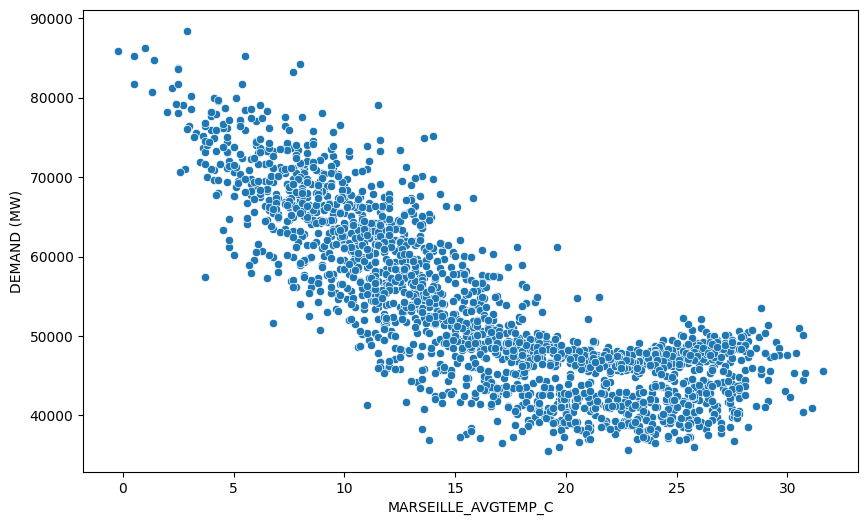

In [ ]:
plt.figure(figsize = (10,6))
sns.scatterplot(x = 'MARSEILLE_AVGTEMP_C' , y = 'DEMAND (MW)' , data = df)

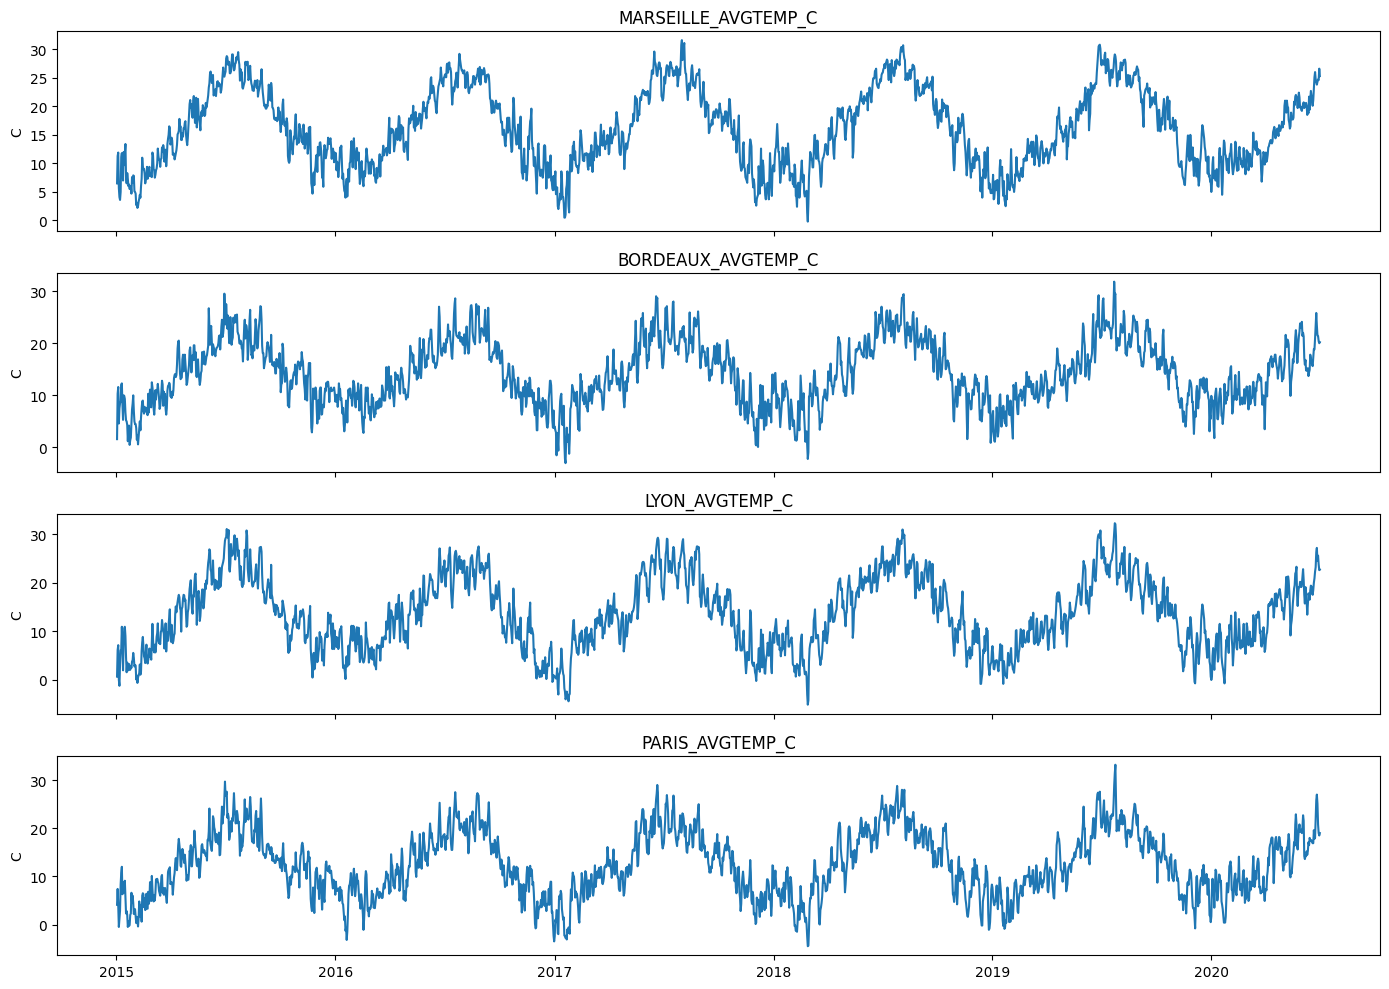

In [ ]:
fig , axes = plt.subplots(4 , 1 , figsize = (14 , 10) , sharex = True )

# plot temperature over time
axes[0].plot(df.index , df['MARSEILLE_AVGTEMP_C'])
axes[0].set_title('MARSEILLE_AVGTEMP_C')
axes[0].set_ylabel('C')


axes[1].plot(df.index , df['BORDEAUX_AVGTEMP_C'])
axes[1].set_title('BORDEAUX_AVGTEMP_C')
axes[1].set_ylabel('C')

axes[2].plot(df.index , df['LYON_AVGTEMP_C'])
axes[2].set_title('LYON_AVGTEMP_C')
axes[2].set_ylabel('C')


axes[3].plot(df.index , df['PARIS_AVGTEMP_C'])
axes[3].set_title('PARIS_AVGTEMP_C')
axes[3].set_ylabel('C')

plt.tight_layout()

In [ ]:
# time series decomposition and ACF and PACF analysis for temperature and demand

In [ ]:
df['Residual_Demand'] = df['DEMAND (MW)'] - df['NUCLEAR AVAIL. (MW)']

<Axes: xlabel='Residual_Demand', ylabel='PRICE (EUR/MWH)'>

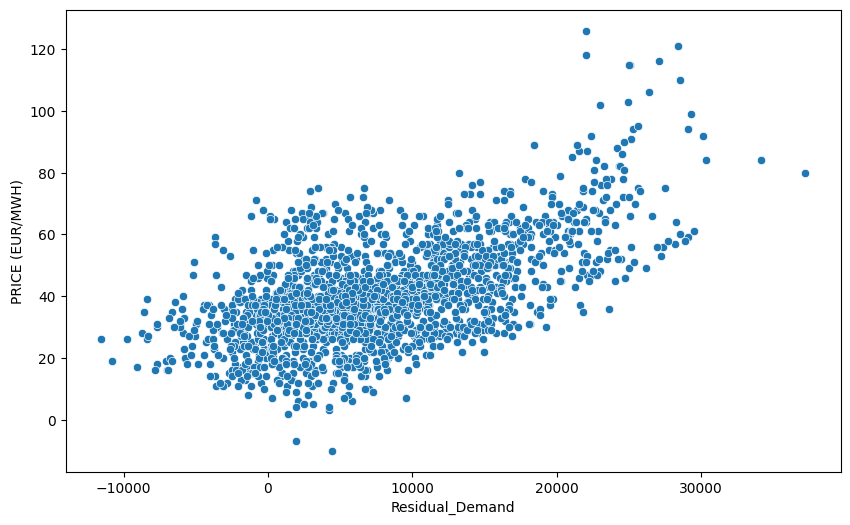

In [ ]:
plt.figure(figsize = (10,6))
sns.scatterplot(x = 'Residual_Demand' , y = 'PRICE (EUR/MWH)' , data = df)

<Axes: xlabel='avg_temp', ylabel='Residual_Demand'>

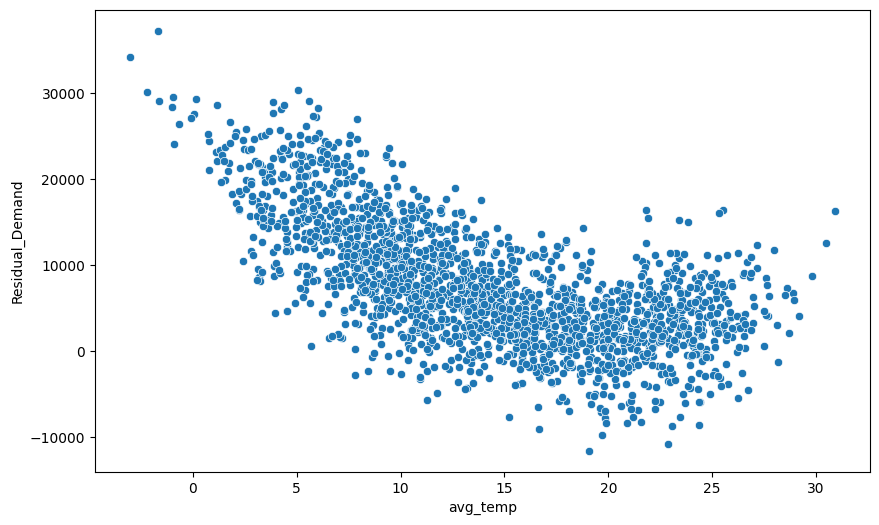

In [ ]:
plt.figure(figsize = (10,6))
sns.scatterplot(x = 'avg_temp' , y ='Residual_Demand' , data = df)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings


# stationarity tests

def test_stationarity(df, columns, max_lag=None):
    """
    Runs ADF and KPSS tests on specified columns to diagnose stationarity.

    Args:
        df (pd.DataFrame): The dataframe containing the time series data.
        columns (list): List of column names to test.
        max_lag (int, optional): Maximum number of lags for the ADF test.

    Returns:
        pd.DataFrame: A dataframe containing the test statistics, p-values, and diagnosis.
    """
    # Suppress KPSS warnings about p-values being out of lookup table bounds
    warnings.filterwarnings("ignore", message="p-value is greater than the indicated p-value")
    warnings.filterwarnings("ignore", message="p-value is smaller than the indicated p-value")

    results = []

    for col in columns:
        series = df[col].dropna()

        # Augmented Dickey-Fuller Test (Non-Stationarity -> has a unit root)
        adf_stat, adf_p, _, _, _, _ = adfuller(series, maxlag=max_lag, autolag='AIC')
        adf_stationary = adf_p < 0.05

        # KPSS Test (Trend-Stationarity)
        kpss_stat, kpss_p, _, _ = kpss(series, regression='c', nlags='auto')
        kpss_stationary = kpss_p > 0.05

        # Diagnosis
        if adf_stationary and kpss_stationary:
            diagnosis = "Stationary"
        elif adf_stationary and not kpss_stationary:
            diagnosis = "Non-Stationary (Needs Deterministic Trend)"
        elif not adf_stationary and not kpss_stationary:
            diagnosis = "Non-Stationary (Needs Differencing)"
        else: # not adf_stationary and kpss_stationary
            diagnosis = "Difference-Stationary"

        results.append({
            'Feature': col,
            'ADF Statistic': adf_stat,
            'ADF p-value': adf_p,
            'KPSS Statistic': kpss_stat,
            'KPSS p-value': kpss_p,
            'Diagnosis': diagnosis
        })

    return pd.DataFrame(results)


# acf and pacf plot testing

def plot_acf_pacf(series, feature_name, lags=40):
    """
    Generates side-by-side ACF and PACF plots for a given time series.

    Args:
        series (pd.Series): The time series data to plot.
        feature_name (str): The name of the feature (used for plot titles).
        lags (int): Number of lags to include in the plots.
    """
    # Drop NAs to prevent statsmodels plotting errors
    clean_series = series.dropna()

    fig, axes = plt.subplots(2, 1, figsize=(16, 5))

    # Plot ACF (Autocorrelation)
    plot_acf(clean_series, lags=lags, ax=axes[0], alpha=0.05, title=f'ACF: {feature_name}')
    axes[0].set_xlabel('Lags')
    axes[0].set_ylabel('Autocorrelation (Pearson)')

    # Plot PACF (Partial Autocorrelation)
    plot_pacf(clean_series, lags=lags, ax=axes[1], alpha=0.05, title=f'PACF: {feature_name}')
    axes[1].set_xlabel('Lags')
    axes[1].set_ylabel('Partial Autocorrelation')

    plt.tight_layout()
    plt.show()

In [ ]:
# from statsmodels.tsa.stattools import adfuller , kpss
# from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# import warnings

# def test_stationarity(df , columns , max_lag = None):
#   """
#   Runs ADF and KPSS tests on specified columns to diagnose stationarity
#   """
#   # Suppress KPSS warnings about p-values being out of lookup table bounds
#   warnings.filterwarnings("ignore", message="p-value is greater than the indicated p-value")
#   warnings.filterwarnings("ignore", message="p-value is smaller than the indicated p-value")

#   results = []

#   for col in columns:
#     series = df[col].dropna()


#     # Augmented Dickey-Fuller Test (Non Stationarity -> has a unit root)
#     adf_stat , adf_p , _ , _ , _ , _ = adfuller(series , maxlag = max_lag , autolag = 'AIC')
#     adf_stationary = adf_p < 0.05

#     # KPSS Test (Trend-Stationarity)
#     kpss_stat , kpss_p , _ , _ = kpss(series , regression = 'c' , nlags = 'auto')
#     kpss_stationary = kpss_p > 0.05

#     # diagnosis
#     if adf_stationary and kpss_stationary:
#       diagnosis = "Stationary"
#     elif adf_stationary and not kpss_stationary:
#       diagnosis = "Non-Stationary (Needs Deterministic Trend)"
#     elif not adf_stationary and not kpss_stationary:
#       diagnosis = "Non-Stationary (Needs Differencing)"
#     else: # not adf_stationary and kpss_stationary
#       diagnosis = "Difference-Stationary"


#     results.append({
#         'Feature' : col,
#         'ADF Statistic' : adf_stat,
#         'ADF p-value' : adf_p,
#         'KPSS Statistic' : kpss_stat,
#         'KPSS p-value' : kpss_p,
#         'Diagnosis': diagnosis
#         })

#   return pd.DataFrame(results)




In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# # 1. Isolate the training chunk (hide the July 2020 holdout data)
# # eda_df = clean_df.loc[:'2020-06-30'].copy()
# # raw_target = df[CONFIG['target']].dropna()
# raw_target = df['DEMAND (MW)'].dropna()


# print("==================================================")
# print(" RAW DATA EDA: WHOLESALE ELECTRICITY SPOT PRICES")
# print("==================================================")

# # 2. Run Stationarity Check on the Raw Target
# # (Assumes your test_stationarity function is already loaded in memory)
# raw_stationarity_report = test_stationarity(pd.DataFrame(raw_target), ['DEMAND (MW)'])
# print("\n--- 1. Stationarity Diagnostic ---")
# print(raw_stationarity_report.to_string(index=False))

# # 3. Plotting Raw ACF and PACF
# fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# # Plot ACF (Autocorrelation)
# plot_acf(raw_target, lags=40, ax=axes[0], alpha=0.05, title=f'ACF (Raw Spot Price: {'DEMAND (MW)'})')
# axes[0].set_xlabel('Lags (Days)')
# axes[0].set_ylabel('Autocorrelation (Pearson)')

# # Plot PACF (Partial Autocorrelation)
# plot_pacf(raw_target, lags=40, ax=axes[1], alpha=0.05, title=f'PACF (Raw Spot Price: {'DEMAND (MW)'})')
# axes[1].set_xlabel('Lags (Days)')
# axes[1].set_ylabel('Partial Autocorrelation')

# plt.tight_layout()
# plt.show()

 TIME SERIES DIAGNOSTICS & EDA 

--- Stationarity Diagnostic: PRICE ---
        Feature  ADF Statistic  ADF p-value  KPSS Statistic  KPSS p-value                                  Diagnosis
PRICE (EUR/MWH)      -3.208336     0.019507        0.487511      0.044479 Non-Stationary (Needs Deterministic Trend)

--- Generating ACF & PACF Plots ---

Plotting Correlograms for: DEMAND (MW)


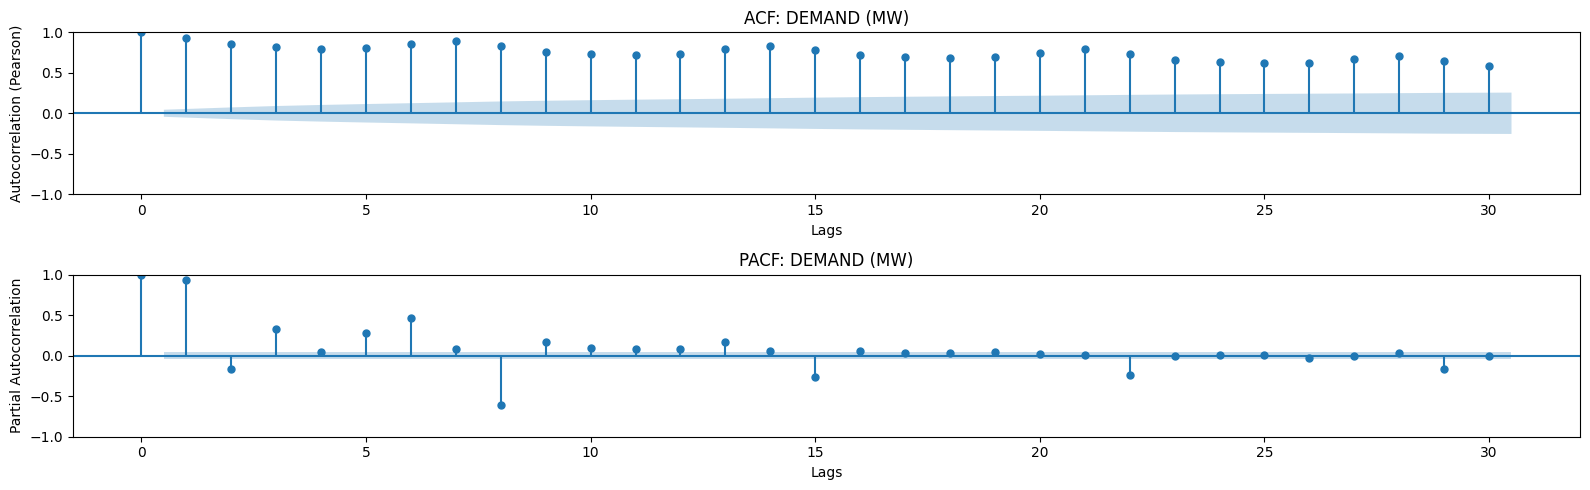


Plotting Correlograms for: avg_temp


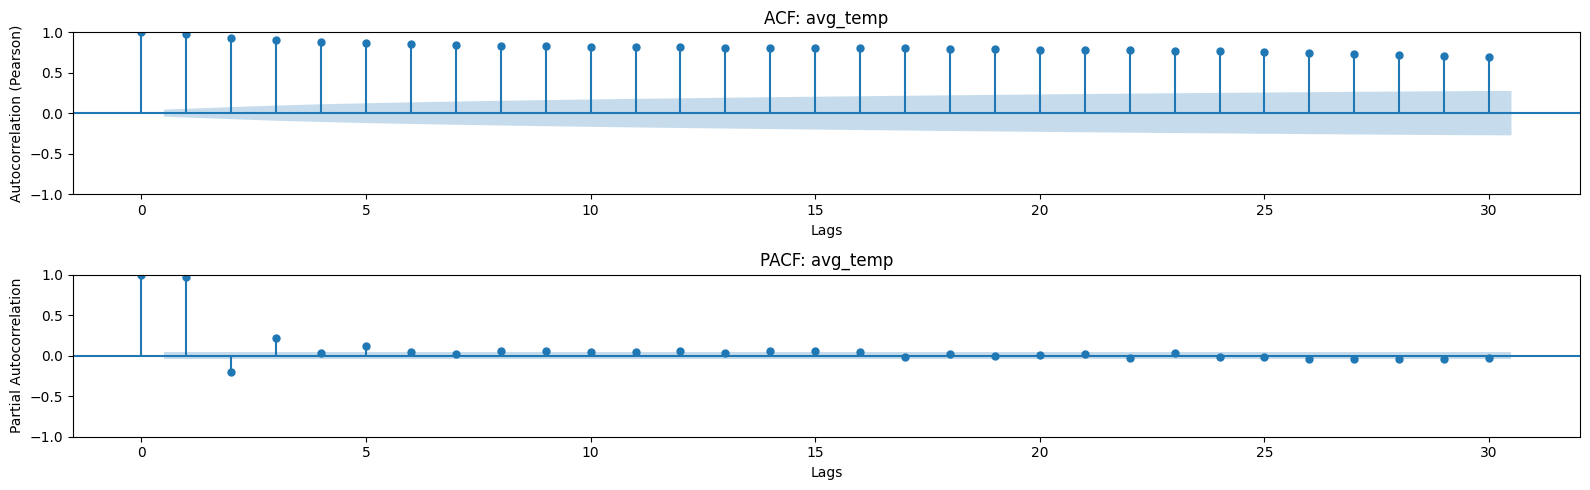


Plotting Correlograms for: PRICE (EUR/MWH)


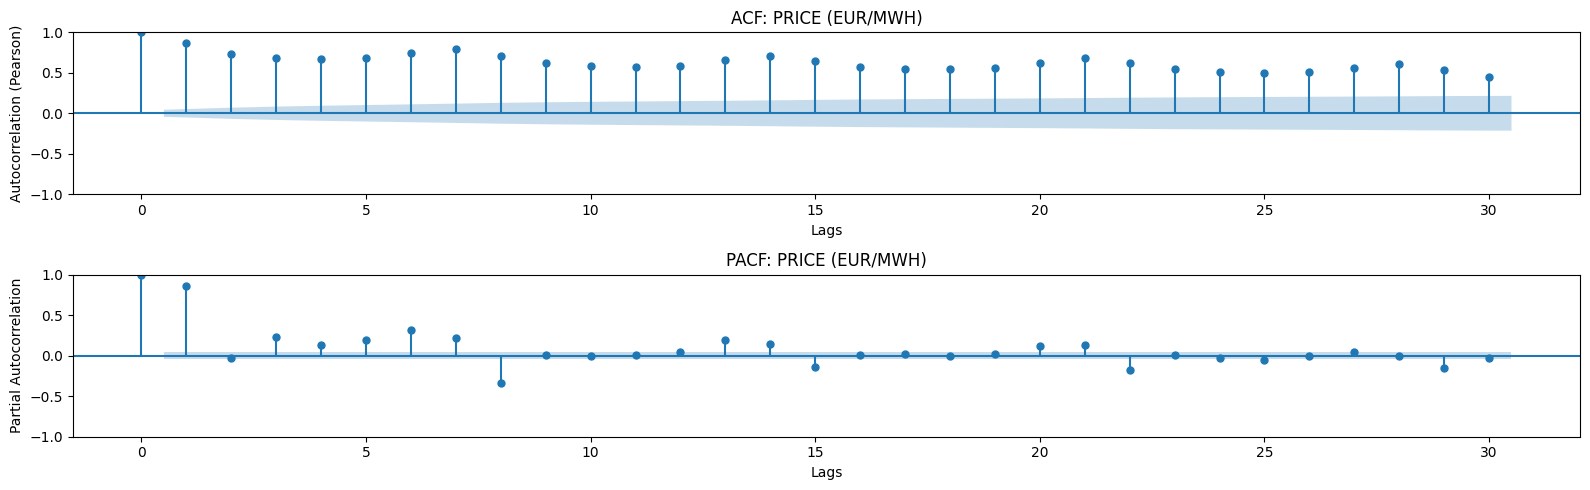

In [ ]:

print("==================================================")
print(" TIME SERIES DIAGNOSTICS & EDA ")
print("==================================================")

# ---------------------------------------------------------
# 1. Stationarity Check (Only on the Price column)
# ---------------------------------------------------------
print("\n--- Stationarity Diagnostic: PRICE ---")
price_col = 'PRICE (EUR/MWH)'
stationarity_report = test_stationarity(df, [price_col])
print(stationarity_report.to_string(index=False))


# ---------------------------------------------------------
# 2. ACF & PACF Plots (Demand, Temperature, Price)
# ---------------------------------------------------------
print("\n--- Generating ACF & PACF Plots ---")

features_to_plot = ['DEMAND (MW)', 'avg_temp', 'PRICE (EUR/MWH)' ]

for feature in features_to_plot:
    print(f"\nPlotting Correlograms for: {feature}")
    plot_acf_pacf(series=df[feature], feature_name=feature, lags=30)

 TRANSFORMED DATA EDA: ROBUST ARCSINH PRICES

--- 1. Stationarity Diagnostic ---
          Feature  ADF Statistic  ADF p-value  KPSS Statistic  KPSS p-value                                  Diagnosis
Transformed_Price      -3.097961     0.026704        0.497061      0.042329 Non-Stationary (Needs Deterministic Trend)

--- 2. Correlograms ---


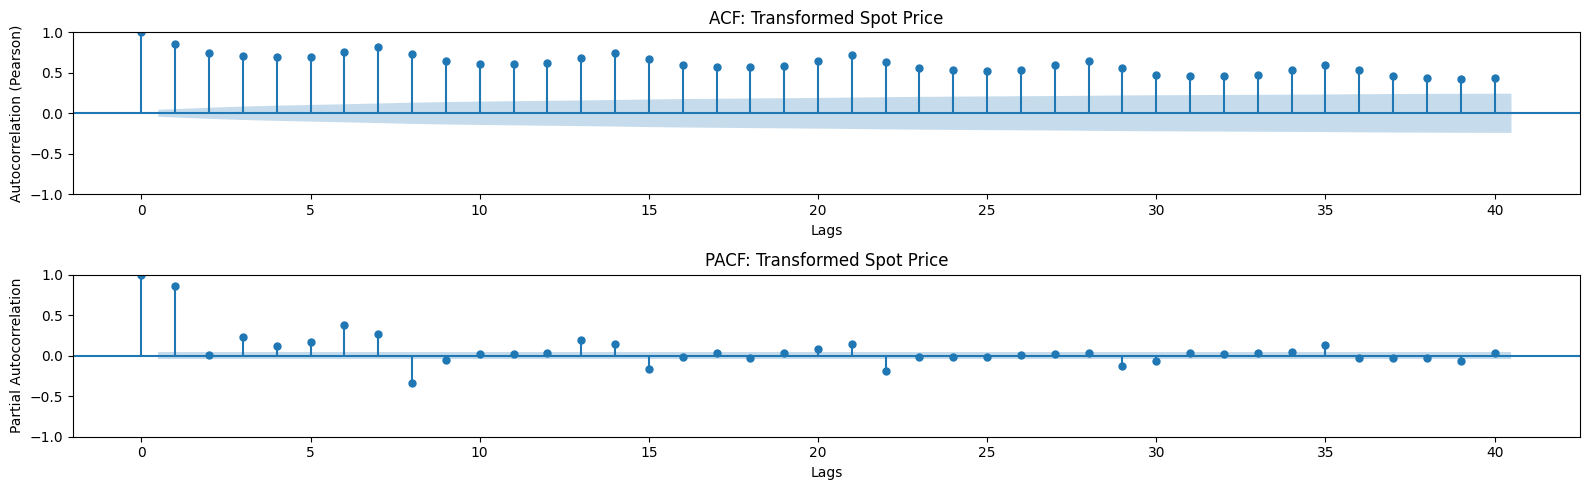

In [ ]:
import pandas as pd

# 1. Isolate the training chunk
# Make sure to only fit the transformer on the training data to avoid leakage!
train_target = df[CONFIG['target']].loc[:'2020-06-30'].dropna()

# 2. Manually apply the target transformation
eda_transformer = RobustArcSinTransformer()
eda_transformer.fit(train_target)
transformed_array = eda_transformer.transform(train_target)

# Convert back to a pandas Series for the modular functions
transformed_target = pd.Series(
    transformed_array,
    index=train_target.index,
    name='Transformed_Price'
)

print("==================================================")
print(" TRANSFORMED DATA EDA: ROBUST ARCSINH PRICES")
print("==================================================")

# 3. Run Stationarity Check using the modular function
transformed_stationarity_report = test_stationarity(pd.DataFrame(transformed_target), ['Transformed_Price'])
print("\n--- 1. Stationarity Diagnostic ---")
print(transformed_stationarity_report.to_string(index=False))

# 4. Plot ACF and PACF using the modular function
print("\n--- 2. Correlograms ---")
plot_acf_pacf(series=transformed_target, feature_name='Transformed Spot Price', lags=40)

 STL DECOMPOSITION: WHOLESALE ELECTRICITY PRICES


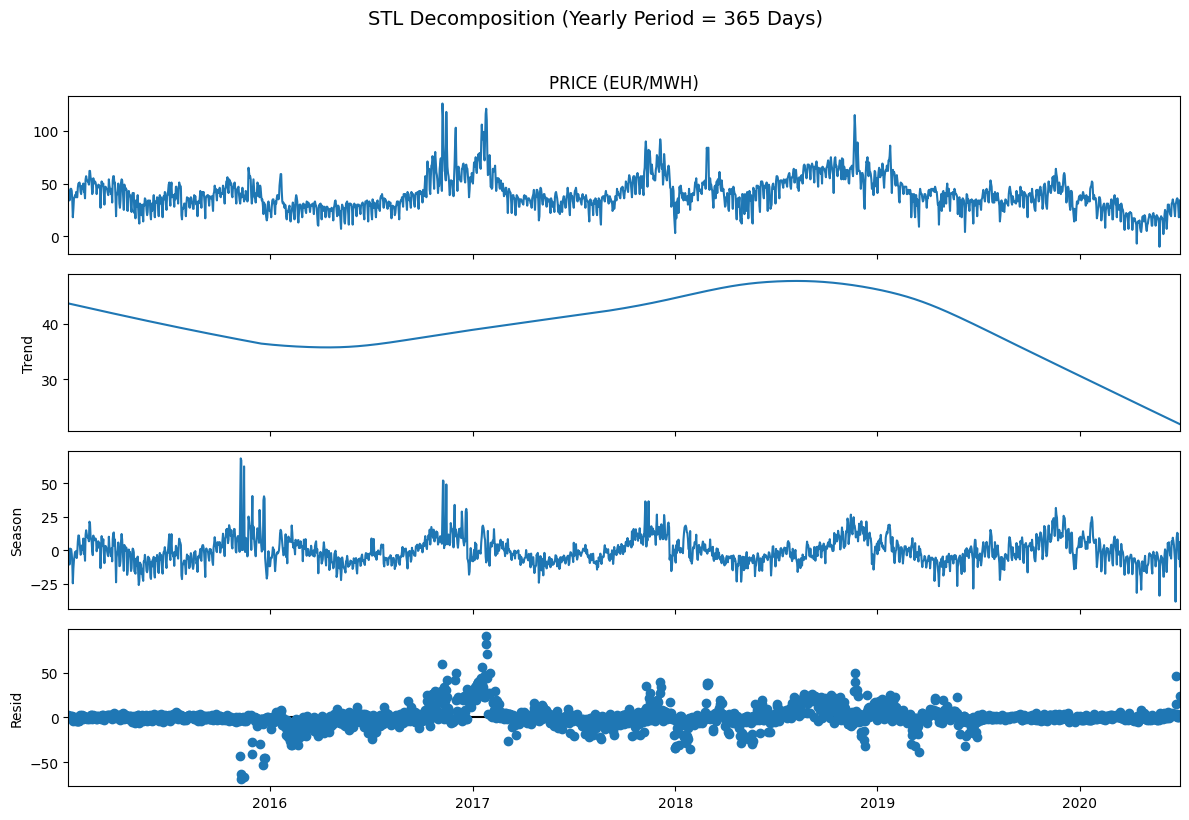

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

# 1. Isolate the target series (Training data only to avoid leakage)
eda_df = df.loc[:'2020-06-30'].copy()
raw_target = eda_df[CONFIG['target']].dropna()

print("==================================================")
print(" STL DECOMPOSITION: WHOLESALE ELECTRICITY PRICES")
print("==================================================")

# 2. Perform STL Decomposition
# period=365 isolates the yearly seasonality (Summer vs. Winter)
# robust=True ensures the massive price spikes don't warp the underlying trend line
stl = STL(raw_target, period=365, robust=True)
result = stl.fit()

# 3. Plot the results
fig = result.plot()
fig.set_size_inches(12, 8)
plt.suptitle('STL Decomposition (Yearly Period = 365 Days)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 27.7 MB/s eta 0:00:00


In [98]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error , root_mean_squared_error
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LinearRegression
import optuna
import shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create the test blocks for the 12-month backtest span
# backtest_schedule = [
#     {"test_start": "2019-07-01", "test_end": "2019-07-31", "regime": "Normal Summer"},
#     {"test_start": "2019-08-01", "test_end": "2019-08-31", "regime": "Summer Holiday Dip"},
#     {"test_start": "2019-09-01", "test_end": "2019-09-30", "regime": "Autumn Transition"},
#     {"test_start": "2019-10-01", "test_end": "2019-10-31", "regime": "Winter Ramp-Up"},
#     {"test_start": "2019-11-01", "test_end": "2019-11-30", "regime": "Heating Season"},
#     {"test_start": "2019-12-01", "test_end": "2019-12-31", "regime": "Peak Winter Load"},
#     {"test_start": "2020-01-01", "test_end": "2020-01-31", "regime": "Peak Winter Load"},
#     {"test_start": "2020-02-01", "test_end": "2020-02-29", "regime": "Late Winter Heating"}, # Leap year
#     {"test_start": "2020-03-01", "test_end": "2020-03-31", "regime": "COVID-19 Outbreak"},
#     {"test_start": "2020-04-01", "test_end": "2020-04-30", "regime": "Lockdown / Price Slump"},
#     {"test_start": "2020-05-01", "test_end": "2020-05-31", "regime": "Demand Collapse"},
#     {"test_start": "2020-06-01", "test_end": "2020-06-30", "regime": "Early Summer Transition"}
# ]


# extended_summer
backtest_schedule = [
    # --- 2018 Warm Season ---
    {"test_start": "2018-05-01", "test_end": "2018-05-31", "regime": "Spring Transition (2018)"},
    {"test_start": "2018-06-01", "test_end": "2018-06-30", "regime": "Early Summer (2018)"},
    {"test_start": "2018-07-01", "test_end": "2018-07-31", "regime": "July Vacations (2018)"},
    {"test_start": "2018-08-01", "test_end": "2018-08-31", "regime": "August Industrial Trough (2018)"},
    {"test_start": "2018-09-01", "test_end": "2018-09-30", "regime": "Back to School / Autumn (2018)"},

    # --- 2019 Warm Season ---
    {"test_start": "2019-05-01", "test_end": "2019-05-31", "regime": "Spring Transition (2019)"},
    {"test_start": "2019-06-01", "test_end": "2019-06-30", "regime": "Early Summer (2019)"},
    {"test_start": "2019-07-01", "test_end": "2019-07-31", "regime": "July Vacations (2019)"},
    {"test_start": "2019-08-01", "test_end": "2019-08-31", "regime": "August Industrial Trough (2019)"},
    {"test_start": "2019-09-01", "test_end": "2019-09-30", "regime": "Back to School / Autumn (2019)"},

    # --- 2020 Pre-Holdout ---
    {"test_start": "2020-05-01", "test_end": "2020-05-31", "regime": "COVID-19 Demand Collapse (2020)"},
    {"test_start": "2020-06-01", "test_end": "2020-06-30", "regime": "Lockdown Easing / Early Summer (2020)"}
]

# core_summer
# backtest_schedule = [
#     # --- 2017 Core Summer ---
#     {"test_start": "2017-06-01", "test_end": "2017-06-30", "regime": "Early Summer (2017)"},
#     {"test_start": "2017-07-01", "test_end": "2017-07-31", "regime": "July Vacations (2017)"},
#     {"test_start": "2017-08-01", "test_end": "2017-08-31", "regime": "August Trough (2017)"},

#     # --- 2018 Core Summer ---
#     {"test_start": "2018-06-01", "test_end": "2018-06-30", "regime": "Early Summer (2018)"},
#     {"test_start": "2018-07-01", "test_end": "2018-07-31", "regime": "July Vacations (2018)"},
#     {"test_start": "2018-08-01", "test_end": "2018-08-31", "regime": "August Trough (2018)"},

#     # --- 2019 Core Summer ---
#     {"test_start": "2019-06-01", "test_end": "2019-06-30", "regime": "Early Summer (2019)"},
#     {"test_start": "2019-07-01", "test_end": "2019-07-31", "regime": "July Vacations (2019)"},
#     {"test_start": "2019-08-01", "test_end": "2019-08-31", "regime": "August Trough (2019)"},

#     # --- 2020 Pre-Holdout ---
#     {"test_start": "2020-06-01", "test_end": "2020-06-30", "regime": "Early Summer (2020)"}
# ]

In [99]:
CONFIG = {
    # 'data_path' : "/content/drive/MyDrive/epex_fr_temp_train.csv",
    'data_path' : "/content/epex_fr_temp_train.csv",
    'date_col' : 'Date',
    'date_format' : '%Y-%m-%d',
    'target' : 'PRICE (EUR/MWH)',
    'features' : {
        'weather' : ['PARIS_AVGTEMP_C' , 'LYON_AVGTEMP_C' , 'BORDEAUX_AVGTEMP_C' , 'MARSEILLE_AVGTEMP_C'],
        'market' : ['NUCLEAR AVAIL. (MW)' , 'DEMAND (MW)']
    }
}

In [100]:
def ingest_data(config):
  """Load raw data and enforce datetime indexing"""
  print(f"Loading data from ... {config['data_path']}")
  df = pd.read_csv(config['data_path'])
  df[config['date_col']] = pd.to_datetime(df[config['date_col']] , format = config['date_format'])
  df.set_index(config['date_col'] , inplace=True)
  df.sort_index(inplace=True)


  print(f"data loaded successfully... Shape {df.shape}")
  return df

In [101]:
def preprocess_data(df):
    """Cleans data by handling duplicates, enforcing daily frequency, and interpolation"""
    print("Preprocessing data ...")

    # Handle duplicate dates
    if df.index.duplicated().any():
        dupes = df.index.duplicated().sum()
        print(f"Removing {dupes} duplicate index entries.")
        df = df[~df.index.duplicated(keep='first')]

    # Enforce Strict daily frequency (THE FIX)
    expected_days = pd.date_range(df.index.min() , df.index.max() , freq = 'D')
    missing_days = expected_days[~expected_days.isin(df.index)].shape[0]

    if missing_days > 0:
        print(f"Reindexing and interpolating {missing_days} missing values...") # Added f-string
        df = df.reindex(expected_days) # Force the missing dates into the dataframe as NaNs
        df = df.interpolate(method='time') # Now interpolate can actually fill them

    print("Preprocessing complete")
    return df

In [102]:
def engineer_residual_demand(df , demand_col = 'DEMAND (MW)' , nuclear_col = 'NUCLEAR AVAIL. (MW)'):
  df_eng = df.copy()

  # base residual demand
  df_eng['Residual_Demand'] = df[demand_col] - df[nuclear_col]

  # polynomial terms
  df_eng['Residual_Demand_sq'] = df_eng['Residual_Demand'] ** 2
  df_eng['Residual_Demand_cu'] = df_eng['Residual_Demand'] ** 3
  return df_eng

In [103]:
def engineer_degree_days(df , temp_features , heating_threshold = 15 , cooling_threshold = 22):
  """
  converting temperature into HDD and CDD
  """
  df_engineered = df.copy()

  for col in temp_features:
    # region should depict here the region temperature columns
    df_engineered[f'{col}_HDD'] = np.maximum(heating_threshold - df_engineered[col] , 0)
    df_engineered[f'{col}_CDD'] = np.maximum(df_engineered[col] - cooling_threshold , 0)

  return df_engineered

In [104]:
import holidays
import numpy as np

def engineer_calendar_features(df):
    """
    Extracts calendar-based indicators and highly specific French industrial regimes.
    """
    df_engineered = df.copy()

    # 1. Base Calendar Features
    df_engineered['year'] = df_engineered.index.year
    df_engineered['month'] = df_engineered.index.month
    df_engineered['day_of_year'] = df_engineered.index.dayofyear
    df_engineered['day_of_week'] = df_engineered.index.dayofweek
    df_engineered['is_weekend'] = df_engineered['day_of_week'].isin([5,6]).astype(int)


    # 2. Holidays
    unique_years = df_engineered.index.year.unique().tolist()
    fr_holidays = holidays.France(years=unique_years)
    df_engineered['is_holiday'] = df_engineered.index.isin(fr_holidays).astype(int)

    # 3. COVID-19 Lockdown
    date_strings = df_engineered.index.strftime('%Y-%m-%d')
    df_engineered['is_lockdown'] = ((date_strings >= '2020-03-17') & (date_strings <= '2020-05-11')).astype(int)

    # ==========================================
    # 4. FRENCH SUMMER VACATION PHASES
    # ==========================================
    month = df_engineered.index.month
    day = df_engineered.index.day
    day_of_week = df_engineered.index.dayofweek

    # Phase A: School End July (July 1 to July 13)
    df_engineered['is_school_end_july'] = ((month == 7) & (day >= 1) & (day <= 13)).astype(int)

    # Phase B: Bastille Day & Dynamic Bridge Days
    is_bastille = (month == 7) & (day == 14)
    is_monday_bridge = (month == 7) & (day == 13) & (day_of_week == 0)
    is_friday_bridge = (month == 7) & (day == 15) & (day_of_week == 4)

    df_engineered['is_bastille_bridge'] = (is_bastille | is_monday_bridge | is_friday_bridge).astype(int)

    # Phase C: Grandes Vacances (July 15 to July 31)
    df_engineered['is_grandes_vacances_july'] = ((month == 7) & (day >= 15) & (day <= 31)).astype(int)

    # Enforce non-overlapping boundaries for bridge days
    df_engineered.loc[df_engineered['is_bastille_bridge'] == 1, 'is_school_end_july'] = 0
    df_engineered.loc[df_engineered['is_bastille_bridge'] == 1, 'is_grandes_vacances_july'] = 0

    # August Trough
    df_engineered['is_august_vacation'] = (month == 8).astype(int)

    # ==========================================
    # 5. Cyclical Encoding
    # ==========================================
    df_engineered['sin_day_of_year'] = np.sin(2 * np.pi * df_engineered['day_of_year'] / 365)
    df_engineered['cos_day_of_year'] = np.cos(2 * np.pi * df_engineered['day_of_year'] / 365)

    return df_engineered














# import holidays
# def engineer_calendar_features(df):
#   """
#   extract calendar based indicators
#   """
#   df_engineered = df.copy()

#   df_engineered['year'] = df_engineered.index.year
#   df_engineered['month'] = df_engineered.index.month
#   df_engineered['day_of_year'] = df_engineered.index.dayofyear
#   df_engineered['day_of_week'] = df_engineered.index.dayofweek
#   df_engineered['is_weekend'] = df_engineered['day_of_week'].isin([5,6]).astype(int)


#   # fetch the french holiday calendar
#   unique_years = df_engineered.index.year.unique().tolist()
#   fr_holidays = holidays.France(years = unique_years)

#   df_engineered['is_holiday'] = df_engineered.index.isin(fr_holidays).astype(int)

#   # weekends and holidays into non working
#   df_engineered['is_non_working'] = (df_engineered['is_weekend'] | df_engineered['is_holiday']).astype(int)

#   # covid 19 lockdown
#   date_strings = df_engineered.index.strftime('%Y-%m-%d')
#   df_engineered['is_lockdown'] = ((date_strings >= '2020-03-17') & (date_strings <= '2020-05-11')).astype(int)


#   # july vacation
#   df_engineer


#   # cyclical encoding
#   df_engineered['sin_day_of_year'] = np.sin(2 * np.pi * df_engineered['day_of_year'] / 365)
#   df_engineered['cos_day_of_year'] = np.cos(2 * np.pi * df_engineered['day_of_year'] / 365)



#   # also construct cyclic sine and cosine features

#   return df_engineered


In [105]:
def engineer_national_temperature(df , is_train=True , t_norm_reference= None):
  """
  calculating the weighted national temperature , exponentially smoothed thermal inertia(T_lisse), and the thermal deviation from the seasona norm
  """

  df_eng = df.copy()

  weights = {
      'PARIS_AVGTEMP_C' : 0.69,
      'LYON_AVGTEMP_C' : 0.13,
      'MARSEILLE_AVGTEMP_C': 0.10,
      'BORDEAUX_AVGTEMP_C': 0.08
  }

  # calculate T_raw (weighted average)

  df_eng['T_raw'] = sum(df_eng[region] * weight for region , weight in weights.items())


  # Calculate T_lisse (Exponential Smoothing for building inertia)
  df_eng['T_lisse'] = df_eng['T_raw'].ewm(alpha = 0.5).mean()

  if is_train:
    t_norm_reference = df_eng.groupby(df_eng.index.dayofyear)['T_lisse'].mean()

  df_eng['T_norm'] = df_eng.index.dayofyear.map(t_norm_reference)

  df_eng['Delta_T'] = df_eng['T_lisse'] - df_eng['T_norm']

  return df_eng , t_norm_reference




In [106]:
def simulate_exogenous_pipeline(train_data, test_data, test_start, test_end,
                                region_cols, HDD_CDD_COL_REF, calendar_features, hdd_cdd_cols, demand_col='DEMAND (MW)'):
    """
    Executes the cascading simulation (Weather -> Thermal -> Demand -> Residual)
    Returns the fully enriched training data and simulated test data.
    """
    simulated_test_data = test_data.copy()

    # ==========================================
    # STEP 1: FORECAST WEATHER
    # ==========================================
    weather_model = WeatherForecaster(region_columns=region_cols)
    weather_model.fit(train_data)

    horizon = len(simulated_test_data)
    last_two_days_actuals = train_data.iloc[-2:]
    forecasted_weather = weather_model.predict(test_start, horizon, last_two_days_actuals)

    for col in region_cols:
        simulated_test_data[col] = forecasted_weather[col].values

    # ==========================================
    # STEP 2: STITCH & SMOOTH (Thermal Features)
    # ==========================================
    # Train Data Normal Baseline & Features
    enriched_train, t_norm_ref = engineer_national_temperature(train_data, is_train=True)
    enriched_train = engineer_degree_days(enriched_train, HDD_CDD_COL_REF)

    # Stitching for Test Data Inertia
    warmup_period = enriched_train.iloc[-14:].copy()
    stitched_data = pd.concat([warmup_period, simulated_test_data]) # Fixed syntax error here

    # Test Data Smoothing
    stitched_data, _ = engineer_national_temperature(stitched_data, is_train=False, t_norm_reference=t_norm_ref)
    stitched_data = engineer_degree_days(stitched_data, HDD_CDD_COL_REF)

    simulated_test_data = stitched_data.loc[test_start:test_end].copy()

    # ==========================================
    # STEP 3: FORECAST DEMAND
    # ==========================================
    load_model = LoadForecaster(calendar_features=calendar_features, hdd_cdd_columns=hdd_cdd_cols)
    load_model.fit(enriched_train, demand_col)

    forecasted_demand = load_model.predict(simulated_test_data)
    simulated_test_data[demand_col] = forecasted_demand.values

    # ==========================================
    # STEP 4: RE-CALCULATE RESIDUAL DEMAND
    # ==========================================
    simulated_test_data = engineer_residual_demand(simulated_test_data, demand_col, 'NUCLEAR AVAIL. (MW)')

    # remove
    enriched_train = enriched_train.drop(columns=region_cols, errors='ignore')
    simulated_test_data = simulated_test_data.drop(columns=region_cols, errors='ignore')

    return enriched_train, simulated_test_data

In [107]:
def run_backtest(df, target_col, features, model, model_name, schedule, region_cols, calendar_features, HDD_CDD_COL_REF, hdd_cdd_cols, demand_col='DEMAND (MW)'):
    all_fold_metrics = []
    all_fold_preds = []

    print(f"starting 12-fold walk-forward backtest...")

    for idx, fold in enumerate(schedule, 1):
        test_start = pd.Timestamp(fold['test_start'])
        test_end = pd.Timestamp(fold['test_end'])

        train_start = test_start - pd.Timedelta(days=731)
        train_end = test_start - pd.Timedelta(days=1)

        # 1. Slice data
        train_data = df.loc[train_start:train_end].copy()
        test_data = df.loc[test_start:test_end].copy()

        # 2. Run Exogenous Simulation Engine
        enriched_train, simulated_test = simulate_exogenous_pipeline(
            train_data, test_data, test_start, test_end,
            region_cols, HDD_CDD_COL_REF, calendar_features, hdd_cdd_cols, demand_col
        )

        # 3. Train the Price Model
        X_train = enriched_train[features]
        y_train = enriched_train[target_col]

        X_test_simulated = simulated_test[features]
        y_test = simulated_test[target_col]

        model.fit(X_train, y_train)
        preds = model.predict(X_test_simulated)

        # 4. Calculate metrics
        mae = mean_absolute_error(y_test, preds)
        rmse = root_mean_squared_error(y_test, preds)

        all_fold_metrics.append({
            'model': model_name, 'fold': idx,
            'train_start': train_start, 'train_end': train_end,
            'test_start': test_start, 'test_end': test_end,
            'mae': mae, 'rmse': rmse
        })

        all_fold_preds.append(pd.DataFrame({
            "model": model_name, "actual_price": y_test,
            "predicted_price": preds, "regime": fold['regime'], "fold": idx
        }, index=test_data.index))

        print(f"Fold {idx:02d} ({fold['regime']}): MAE = {mae:.2f} EUR/MWh | RMSE = {rmse:.2f} EUR/MWh")

    print("="*50 + "\nBacktest Complete.")
    return pd.DataFrame(all_fold_metrics), pd.concat(all_fold_preds)

In [108]:
def forecast_holdout(train_df, pred_df, target_col, features, best_pipeline,
                     holdout_start, holdout_end, region_cols, calendar_features, HDD_CDD_COL_REF, hdd_cdd_cols, demand_col='DEMAND (MW)'):

    print(f"Generating final forecast for {holdout_start} to {holdout_end}...")

    test_start = pd.to_datetime(holdout_start, format='%Y-%m-%d')
    test_end = pd.to_datetime(holdout_end, format='%Y-%m-%d')

    train_start = test_start - pd.Timedelta(days=731)
    train_end = test_start - pd.Timedelta(days=1)

    # 1. Slice data
    train_data = train_df.loc[train_start:train_end].copy()
    test_data = pred_df.loc[test_start:test_end].copy()

    # 2. Run Exogenous Simulation Engine
    enriched_train, simulated_test = simulate_exogenous_pipeline(
        train_data, test_data, test_start, test_end,
        region_cols, HDD_CDD_COL_REF, calendar_features, hdd_cdd_cols, demand_col
    )

    # 3. Train Price Model & Predict
    X_train = enriched_train[features]
    y_train = enriched_train[target_col]
    X_test_simulated = simulated_test[features]

    best_pipeline.fit(X_train, y_train)
    predictions = best_pipeline.predict(X_test_simulated)

    results_df = pd.DataFrame({'predicted_price': predictions}, index=test_data.index)

    # 4. Extract SHAP Matrices
    X_train_raw = pd.DataFrame(X_train, columns=X_train.columns, index=X_train.index)
    X_test_raw = pd.DataFrame(X_test_simulated, columns=X_test_simulated.columns, index=X_test_simulated.index)

    print("Final forecast complete.")
    return best_pipeline, X_train_raw, X_test_raw, results_df

In [ ]:
from sklearn.base import BaseEstimator , RegressorMixin
class NaiveForecaster(BaseEstimator , RegressorMixin):
  """
  unified baseline forecaster

  Strategies:
  - 'last': Predicts the exact last known value(Simple Naive)
  - 'mean': Predicts historical average
  - 'median': Predicts historical meadian
  - 'seasonal': Predicts the value from exactly 'shift_days' ago
  """


  def __init__(self , strategy = 'last' , shift_days = 'mean'):
    self.strategy = strategy
    self.shift_days = shift_days

    self.learned_value = None
    self.history_y = None

  def fit(self ,X , y):
    if self.strategy == 'last':
      self.learned_value = y.iloc[-1]
    elif self.strategy == 'mean':
      self.learned_value = y.mean()
    elif self.strategy == 'median':
      self.learned_value = y.median()
    elif self.strategy == 'seasonal':
      self.history_y = y.copy()
    else:
      raise ValueError(f"Unknown strategy {self.strategy}")
    return self

  def predict(self , X):
    n_predictions = len(X)

    if self.strategy in ['last' , 'mean' , 'median']:
      return np.full(shape=(n_predictions,) , fill_value = self.learned_value)

    elif self.strategy == 'seasonal':
      target_historical_dates = X.index - pd.Timedelta(days = self.shift_days)
      predictions = self.history_y.reindex(target_historical_dates , method='nearest')
      return predictions.values


In [110]:
from sklearn.base import BaseEstimator , TransformerMixin

class RobustArcSinTransformer(BaseEstimator , TransformerMixin):
  """
  applies MAD scaling and Inverse Hyperbolic Sine transformation
  """

  def __init__(self):
    self.median_ = None
    self.mad_ = None
    self.z_75 = 0.6745

  def fit(self , X , y = None):
    X_arr = np.asarray(X)

    # calculate median and MAD from training window
    self.median_ = np.median(X_arr)
    self.mad_ = np.median(np.abs(X_arr - self.median_))

    if self.mad_ == 0:
      self.mad_ = 1e-6

    return self

  def transform(self , X , y=None):
    X_arr = np.asarray(X)

    # Robust Scaling
    y_t = (1 / self.z_75) * ((X_arr - self.median_) / self.mad_)

    return np.arcsinh(y_t)

  def inverse_transform(self , X , y=None):
    X_arr = np.asarray(X)

    # Inverse Robust Scaling
    return  self.z_75 * np.sinh(X_arr) * self.mad_ + self.median_


In [111]:
class WeatherForecaster:
  def __init__(self , region_columns):
    self.regions = region_columns
    self.coefficients = {}
    self.start_date_hist = None

  def _remove_leap_days(self , df):
    return df[~((df.index.month == 2) & (df.index.day == 29))].copy()

  def fit(self, train_df):
        # remove feb 29 to keep strict 365-day cycles
        df = self._remove_leap_days(train_df)
        self.start_date_hist = df.index[0]

        # create time index (t)
        df['t'] = np.arange(1, len(df) + 1)

        # Fourier Features
        df['cos_1'] = np.cos(2 * np.pi * 1 * df['t'] / 365)
        df['sin_1'] = np.sin(2 * np.pi * 1 * df['t'] / 365)
        df['cos_2'] = np.cos(2 * np.pi * 2 * df['t'] / 365)
        df['sin_2'] = np.sin(2 * np.pi * 2 * df['t'] / 365)

        # Separate the static features from the dynamic lag features
        base_features = ['t', 'cos_1', 'sin_1', 'cos_2', 'sin_2']

        for region in self.regions:
            # 1. Create uniquely named lag columns for the specific region
            lag_1_col = f'{region}_lag_1'
            lag_2_col = f'{region}_lag_2'

            df[lag_1_col] = df[region].shift(1)
            df[lag_2_col] = df[region].shift(2)

            # 2. Combine base features with the region's specific lags
            region_features = base_features + [lag_1_col, lag_2_col]

            # 3. Drop NaNs using the dynamically built feature list
            train_subset = df.dropna(subset=region_features + [region])
            X = train_subset[region_features]
            y = train_subset[region]

            # 4. Train the model
            model = LinearRegression()
            model.fit(X, y)

            # 5. Store the coefficients exactly as before
            self.coefficients[region] = {
                'a': model.intercept_,
                'b': model.coef_[0],
                'alpha_1': model.coef_[1],
                'beta_1': model.coef_[2],
                'alpha_2': model.coef_[3],
                'beta_2': model.coef_[4],
                'phi_1': model.coef_[5],
                'phi_2': model.coef_[6],
            }

  def predict(self , forecast_start_date , horizon , last_two_days_actuals):
    """
    recursively forecasts temperatures and derives HDD/CDD.
    """
    dates = pd.date_range(start = forecast_start_date , periods = horizon , freq = 'D')
    predicted_paths = {region: [] for region in self.regions}

    t_start = (forecast_start_date - self.start_date_hist).days

    for i, current_date in enumerate(dates):
      # skipping actual execution logic incase of leap day
      is_leap = (current_date.month == 2) and (current_date.day == 29)
      t_current = t_start + i if not is_leap else t_start + i - 1

      for region in self.regions:
        coefs = self.coefficients[region]

        # Deterministic Component
        deterministic = (
            coefs['a'] +
            coefs['b' ] * t_current +
            coefs['alpha_1'] * np.cos(2 * np.pi * 1 * t_current / 365) +
            coefs['beta_1'] * np.sin(2 * np.pi * 1 * t_current / 365) +
            coefs['alpha_2'] * np.cos(2 * np.pi * 2 * t_current / 365) +
            coefs['beta_2'] * np.sin(2 * np.pi * 2 * t_current / 365)
        )

        # AR lags
        if i == 0:
          lag_1 = last_two_days_actuals.iloc[-1][region]
          lag_2 = last_two_days_actuals.iloc[-2][region]
        elif i == 1:
          lag_1 = predicted_paths[region][-1]
          lag_2 = last_two_days_actuals.iloc[-1][region]
        else:
          lag_1 = predicted_paths[region][-1]
          lag_2 = predicted_paths[region][-2]


        pred_t = deterministic + (coefs['phi_1'] * lag_1) + (coefs['phi_2'] * lag_2)
        predicted_paths[region].append(pred_t)


      # Compile results and create HDD / CDD

    forecast_df = pd.DataFrame(predicted_paths , index = dates)
    return forecast_df


In [112]:

from sklearn.linear_model import Ridge

class LoadForecaster:
  def __init__(self , calendar_features , hdd_cdd_columns):
    """
    expects dataframe already with calendar features
    """
    self.features = calendar_features + hdd_cdd_columns

    # choice of model and parameters?
    self.model = Pipeline([
      ('scaler' , StandardScaler()),
      ('ridge' , Ridge(alpha = 1.0 , random_state = 42))
    ])

  def fit(self , train_df , target_col):
    df = train_df.dropna(subset = self.features + [target_col])

    X = df[self.features]
    y = df[target_col]

    self.model.fit(X,y)

  def predict(self , forecasted_features_df):
    X = forecasted_features_df[self.features]
    predictions = self.model.predict(X)
    return pd.Series(predictions , index = forecasted_features_df.index , name = 'forecasted_demand')


In [113]:
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances

class StudyEarlyStoppingCallback:
    """
    Stops the Optuna study if the objective score does not improve
    after a specified number of consecutive trials.
    """
    def __init__(self, early_stopping_rounds: int):
        self.early_stopping_rounds = early_stopping_rounds
        self._best_trial_number = None
        self._stagnant_trials = 0

    def __call__(self, study: optuna.study.Study, trial: optuna.trial.FrozenTrial) -> None:
        # Check if the current trial is the new best trial
        if study.best_trial.number != self._best_trial_number:
            self._best_trial_number = study.best_trial.number
            self._stagnant_trials = 0  # Reset counter
        else:
            self._stagnant_trials += 1 # Increment counter

        # Stop the study if it has stagnated
        if self._stagnant_trials >= self.early_stopping_rounds:
            print(f"\n[Early Stopping] Triggered! No improvement in the last {self.early_stopping_rounds} trials.")
            study.stop()

In [114]:
from sklearn.base import clone

def tune_model(df, target_col, features, schedule, base_pipeline, param_space_func,
               region_cols, calendar_features, HDD_CDD_COL_REF, hdd_cdd_cols, demand_col='DEMAND (MW)', n_trials=100):

    print("Start Optuna Hyperparameter Optimization")

    def objective(trial):
        params = param_space_func(trial)
        model_clone = clone(base_pipeline)
        model_clone.set_params(**params)

        # Make sure run_backtest has verbose=False or you will flood your console
        metrics_df, _ = run_backtest(df, target_col, features, model_clone, 'tuning',
                                     schedule, region_cols, calendar_features,
                                     HDD_CDD_COL_REF, hdd_cdd_cols, demand_col)
        return metrics_df['rmse'].mean()

    # Create study
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction='minimize')

    # Initialize the early stopper (e.g., stop if no improvement for 10 trials)
    early_stopper = StudyEarlyStoppingCallback(early_stopping_rounds=20)

    # Run the optimization WITH the callback
    study.optimize(objective, n_trials=n_trials, callbacks=[early_stopper])

    print("Optuna Hyperparameter Optimization Complete")
    print(f"Best RMSE: {study.best_value:.2f}")

    # ==========================================
    # VISUALIZATION (Interactive Plotly Graphs)
    # ==========================================
    try:
        # 1. The Learning Curve
        fig1 = plot_optimization_history(study)
        fig1.show()

        # 2. Feature Importance for Hyperparameters
        fig2 = plot_param_importances(study)
        fig2.show()
    except Exception as e:
        print("Could not render Optuna plots in this environment.")

    best_pipeline = clone(base_pipeline)
    best_pipeline.set_params(**study.best_params)

    return best_pipeline

In [115]:
from xgboost import XGBRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

target_transformer = RobustArcSinTransformer()
# ---------------------------------------------------------
# 1. Base Pipelines
# ---------------------------------------------------------
elastic_base_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', ElasticNet(random_state=42, max_iter=10000))
])

# XGBoost runs much faster if we enable parallel processing (n_jobs=-1)
xgb_base_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBRegressor(random_state=42, n_jobs=-1,
    tree_method = 'hist',
    # device='cuda'
    )),

])

# ---------------------------------------------------------
# 2. Transformed Target Wrappers
# ---------------------------------------------------------
elastic_transformed_pipeline = TransformedTargetRegressor(
    regressor=elastic_base_pipeline,
    transformer=target_transformer
)

xgb_transformed_pipeline = TransformedTargetRegressor(
    regressor=xgb_base_pipeline,
    transformer=target_transformer
)

# ---------------------------------------------------------
# 3. Model Registry
# ---------------------------------------------------------
model_registry = {
    # Naive Baseline
    "Baseline_Seasonal": {
        "pipeline": NaiveForecaster(strategy='seasonal', shift_days=364),
        "requires_tuning": False,
        "params_space": None
    },

    # Linear Model
    "ElasticNet": {
        "pipeline": elastic_transformed_pipeline,
        "requires_tuning": True,
        "params_space": lambda trial: {
            'regressor__model__alpha': trial.suggest_float('regressor__model__alpha', 0.0001, 10.0, log=True),
            'regressor__model__l1_ratio': trial.suggest_float('regressor__model__l1_ratio', 0.0, 1.0)
        }
    },

    # Tree-Based Ensemble
    # "XGBoost": {
    #     "pipeline": xgb_transformed_pipeline,
    #     "requires_tuning": True,
    #     "params_space": lambda trial: {
    #         # Tree complexity
    #         'regressor__model__max_depth': trial.suggest_int('regressor__model__max_depth', 3, 10),
    #         # Number of trees and learning rate (the core trade-off)
    #         'regressor__model__n_estimators': trial.suggest_int('regressor__model__n_estimators', 100, 1000, step=100),
    #         'regressor__model__learning_rate': trial.suggest_float('regressor__model__learning_rate', 0.01, 0.3, log=True),
    #         # Regularization/Robustness (prevents overfitting to noise)
    #         'regressor__model__subsample': trial.suggest_float('regressor__model__subsample', 0.5, 1.0),
    #         'regressor__model__colsample_bytree': trial.suggest_float('regressor__model__colsample_bytree', 0.5, 1.0)
    #     }
    # }
}

In [116]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb
from sklearn.linear_model import ElasticNet, LinearRegression, Lasso, Ridge

def explain_predictions_shap(model, X_train_raw, X_test_raw, explainer_type='both'):
    """
    Generates SHAP values.
    Can return model_agnostic (EUR/MWh), model_specific (Arcsinh), or both.
    """
    print(f"Generating SHAP values using '{explainer_type}' methodology...")

    shap_results = {}

    # ==========================================
    # 1. MODEL-AGNOSTIC (Original Scale: EUR/MWh)
    # ==========================================
    if explainer_type in ['model_agnostic', 'both']:
        print("\n--- Calculating Model-Agnostic SHAP (EUR/MWh) ---")
        # Sample background data to keep computation fast
        background_data = shap.sample(X_train_raw, 100)

        # Evaluate the FULL pipeline wrapper using the Permutation Explainer
        explainer_agnostic = shap.Explainer(model.predict, background_data)
        shap_values_agnostic = explainer_agnostic(X_test_raw)
        shap_results['model_agnostic'] = shap_values_agnostic

        plt.figure(figsize=(10,6))
        plt.title("SHAP Global Feature Importance - Model Agnostic (EUR/MWh)")
        shap.summary_plot(shap_values_agnostic, X_test_raw, show=False)
        plt.tight_layout()
        plt.show()

        print("Waterfall Plot for July 1, 2020 (Model Agnostic):")
        shap.plots.waterfall(shap_values_agnostic[0])


    # ==========================================
    # 2. MODEL-SPECIFIC (Transformed Scale: Arcsinh)
    # ==========================================
    if explainer_type in ['model_specific', 'both']:
        print("\n--- Calculating Model-Specific SHAP (Arcsinh Scale) ---")

        # Pierce the TransformedTargetRegressor to extract the raw algorithm and scaler
        internal_pipeline = model.regressor_
        scaler = internal_pipeline.named_steps['scaler']
        internal_algo = internal_pipeline.named_steps['model']

        # Scale the data internally specifically for this explainer
        X_train_scaled = pd.DataFrame(scaler.transform(X_train_raw), columns=X_train_raw.columns, index=X_train_raw.index)
        X_test_scaled = pd.DataFrame(scaler.transform(X_test_raw), columns=X_test_raw.columns, index=X_test_raw.index)

        # --- DYNAMIC EXPLAINER ROUTING (THE FIX) ---
        if isinstance(internal_algo, xgb.XGBRegressor):
            print("Detected Tree Model. Using TreeExplainer...")
            explainer_specific = shap.TreeExplainer(internal_algo)
            shap_values_specific = explainer_specific(X_test_scaled)

        elif isinstance(internal_algo, (ElasticNet, LinearRegression, Lasso, Ridge)):
            print("Detected Linear Model. Using LinearExplainer...")
            explainer_specific = shap.LinearExplainer(internal_algo, X_train_scaled)
            shap_values_specific = explainer_specific(X_test_scaled)

        else:
            print("Unknown model type. Falling back to generic Explainer...")
            explainer_specific = shap.Explainer(internal_algo, X_train_scaled)
            shap_values_specific = explainer_specific(X_test_scaled)

        shap_results['model_specific'] = shap_values_specific

        plt.figure(figsize=(10,6))
        plt.title("SHAP Global Feature Importance - Model Specific (Arcsinh)")
        shap.summary_plot(shap_values_specific, X_test_scaled, show=False)
        plt.tight_layout()
        plt.show()

        print("Waterfall Plot for July 1, 2020 (Model Specific):")
        # Modern SHAP API returns an Explanation object directly, making plotting much cleaner
        shap.plots.waterfall(shap_values_specific[0])

    return shap_results

In [117]:

# should be renamed to fetch
def prepare_prediction_data(pred_filepath):

  pred_df = pd.read_csv(pred_filepath)
  pred_df['Date'] = pd.to_datetime(pred_df['Date'], format='%Y-%m-%d')
  pred_df.set_index('Date', inplace=True)

  return pred_df

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_residuals_simple(results_df, model_name):
    """
    Generates a clean, 4-panel diagnostic dashboard focusing purely on
    predicted vs. actuals and error distributions.
    """
    # 1. Filter for the specific model
    df = results_df[results_df['model'] == model_name].copy()

    # Calculate Residuals (Actual - Predicted)
    df['residual'] = df['actual_price'] - df['predicted_price']
    df['day_of_week'] = df.index.dayofweek # 0 = Monday, 6 = Sunday

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    sns.set_theme(style="whitegrid")

    # --- Plot 1: Predicted vs. Actual Scatter ---
    sns.scatterplot(data=df, x='actual_price', y='predicted_price', alpha=0.5, ax=axes[0, 0], color='teal')

    # Add the perfect prediction line (y=x)
    min_val = min(df['actual_price'].min(), df['predicted_price'].min())
    max_val = max(df['actual_price'].max(), df['predicted_price'].max())
    axes[0, 0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

    axes[0, 0].set_title(f"[{model_name}] Predicted vs. Actual", fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel("Actual Price (EUR/MWh)")
    axes[0, 0].set_ylabel("Predicted Price (EUR/MWh)")

    # --- Plot 2: Residuals Over Time ---
    sns.scatterplot(data=df, x=df.index, y='residual', alpha=0.5, ax=axes[0, 1], color='blue')
    axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=2)
    axes[0, 1].set_title("Residuals Over Time", fontsize=14, fontweight='bold')
    axes[0, 1].set_ylabel("Error (Actual - Predicted)")

    # --- Plot 3: Residual Distribution (Histogram) ---
    sns.histplot(df['residual'], kde=True, ax=axes[1, 0], color='purple')
    axes[1, 0].axvline(0, color='red', linestyle='--', linewidth=2)
    axes[1, 0].set_title("Distribution of Residuals", fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel("Error (EUR/MWh)")

    # --- Plot 4: Errors by Day of Week ---
    sns.boxplot(data=df, x='day_of_week', y='residual', ax=axes[1, 1], palette='magma')
    axes[1, 1].axhline(0, color='red', linestyle='--', linewidth=2)
    axes[1, 1].set_title("Errors by Day of Week", fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel("Day of Week (0 = Monday, 6 = Sunday)")

    plt.tight_layout()
    plt.show()

# --- Execution ---
# analyze_residuals_simple(results_df, "ElasticNet")

In [119]:
from sklearn import metrics
def evaluate_model_registry(df , target_col , features , schedule , registry , region_cols , calendar_features , HDD_CDD_COL_REF, hdd_cdd_cols , demand_col = 'DEMAND (MW)'):
  print("Evaluating Model Registry ...")

  all_metrics = []
  all_results = []
  trained_models = {}


  for model_name , model_info in registry.items():
    print(f"Evaluating {model_name} ...")

    if model_info['requires_tuning']:
      print(f"Tuning {model_name} ...")
      final_model = tune_model(df , target_col , features , schedule , model_info['pipeline'] , model_info['params_space'] ,  region_cols , calendar_features ,HDD_CDD_COL_REF , hdd_cdd_cols , demand_col = 'DEMAND (MW)' , n_trials = 50)
    else:
      # for naive forecasts
      final_model = model_info['pipeline']

    # running backtests
    metrics_df , results_df = run_backtest(df , target_col , features , final_model , model_name , schedule , region_cols , calendar_features , HDD_CDD_COL_REF,  hdd_cdd_cols , demand_col = 'DEMAND (MW)')
    all_metrics.append(metrics_df)
    all_results.append(results_df)
    trained_models[model_name] = final_model

  master_metrics_df = pd.concat(all_metrics , ignore_index = True)
  master_results_df = pd.concat(all_results)


  return master_metrics_df , master_results_df , trained_models


Setup, Ingestion, and Feature Engineering

In [120]:
# ---------------------------------------------------------
# 1. FEATURE LIST CONFIGURATIONS
# ---------------------------------------------------------
RESIDUAL_DEMAND_COLS = [
    'Residual_Demand',
    'Residual_Demand_sq',
    'Residual_Demand_cu'
]

REGION_COLS = [
    'BORDEAUX_AVGTEMP_C',
    'LYON_AVGTEMP_C',
    'MARSEILLE_AVGTEMP_C',
    'PARIS_AVGTEMP_C'
]

THERMO_TEMP = [
    'T_lisse',
    'Delta_T'
]

HDD_CDD_COL_REF = ['T_lisse']
HDD_CDD_COLS = [f'{r}_HDD' for r in HDD_CDD_COL_REF] + [f'{r}_CDD' for r in HDD_CDD_COL_REF]

CALENDAR_FEATURES = [
     'year', 'month', 'day_of_year', 'day_of_week',
     'is_weekend', 'is_holiday',
    #  'is_non_working',
     'is_lockdown',
     'sin_day_of_year', 'cos_day_of_year' , 'is_school_end_july' , 'is_bastille_bridge' , 'is_grandes_vacances_july' , 'is_august_vacation'
]

# --- THE SPLIT ---

# LIST A: Used strictly for dropping NAs during initial global setup
INITIAL_CLEANING_COLS = CALENDAR_FEATURES + REGION_COLS + RESIDUAL_DEMAND_COLS + ['NUCLEAR AVAIL. (MW)', 'DEMAND (MW)']

# LIST B: The final list fed into the XGBoost/ElasticNet algorithms
FINAL_MODEL_FEATURES = CALENDAR_FEATURES + HDD_CDD_COLS + THERMO_TEMP + RESIDUAL_DEMAND_COLS + ['NUCLEAR AVAIL. (MW)', 'DEMAND (MW)']


# ---------------------------------------------------------
# 2. GLOBAL DATA PREPARATION
# ---------------------------------------------------------
# Data ingestion
raw_df = ingest_data(CONFIG)

# Data preprocessing
clean_df = preprocess_data(raw_df)

# Feature engineering (STATIC ONLY)
clean_df = engineer_calendar_features(clean_df)
clean_df = engineer_residual_demand(clean_df)

# Target selection
target = CONFIG['target']

# Clean based ONLY on the base inputs available right now
clean_df = clean_df.dropna(subset=INITIAL_CLEANING_COLS + [target])

print("Data preparation complete. Base inputs are clean.")

# add a feature for summmer vacation??




Loading data from ... /content/epex_fr_temp_train.csv
data loaded successfully... Shape (2007, 7)
Preprocessing data ...
Preprocessing complete
Data preparation complete. Base inputs are clean.


/tmp/ipykernel_8804/836675177.py:21: FutureWarning:

The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.



Model Training & Tuning

In [121]:
# model selection and tuning over backtests
metrics_summary, results_df, trained_model = evaluate_model_registry(
    df=clean_df,
    target_col=target,
    features=FINAL_MODEL_FEATURES,
    schedule=backtest_schedule,
    registry=model_registry,
    region_cols=REGION_COLS,
    calendar_features=CALENDAR_FEATURES,
    hdd_cdd_cols=HDD_CDD_COLS,
    HDD_CDD_COL_REF=HDD_CDD_COL_REF
)

print("backtesting and tuning complete")


Evaluating Model Registry ...
Evaluating Baseline_Seasonal ...
starting 12-fold walk-forward backtest...
Fold 01 (Spring Transition (2018)): MAE = 8.35 EUR/MWh | RMSE = 10.33 EUR/MWh
Fold 02 (Early Summer (2018)): MAE = 11.33 EUR/MWh | RMSE = 13.52 EUR/MWh
Fold 03 (July Vacations (2018)): MAE = 16.65 EUR/MWh | RMSE = 17.71 EUR/MWh
Fold 04 (August Industrial Trough (2018)): MAE = 26.16 EUR/MWh | RMSE = 26.76 EUR/MWh
Fold 05 (Back to School / Autumn (2018)): MAE = 25.07 EUR/MWh | RMSE = 26.18 EUR/MWh
Fold 06 (Spring Transition (2019)): MAE = 9.52 EUR/MWh | RMSE = 12.48 EUR/MWh
Fold 07 (Early Summer (2019)): MAE = 13.17 EUR/MWh | RMSE = 14.97 EUR/MWh
Fold 08 (July Vacations (2019)): MAE = 14.55 EUR/MWh | RMSE = 15.52 EUR/MWh
Fold 09 (August Industrial Trough (2019)): MAE = 25.16 EUR/MWh | RMSE = 25.72 EUR/MWh
Fold 10 (Back to School / Autumn (2019)): MAE = 26.50 EUR/MWh | RMSE = 27.15 EUR/MWh
Fold 11 (COVID-19 Demand Collapse (2020)): MAE = 21.84 EUR/MWh | RMSE = 22.79 EUR/MWh
Fold 12 (Lo

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning:

Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.433e+00, tolerance: 1.557e-01



Fold 03 (July Vacations (2018)): MAE = 17.81 EUR/MWh | RMSE = 18.68 EUR/MWh


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning:

Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.838e+00, tolerance: 1.413e-01



Fold 04 (August Industrial Trough (2018)): MAE = 21.86 EUR/MWh | RMSE = 22.25 EUR/MWh
Fold 05 (Back to School / Autumn (2018)): MAE = 19.41 EUR/MWh | RMSE = 20.03 EUR/MWh


...

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning:

Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.196e+00, tolerance: 1.367e-01



Fold 11 (COVID-19 Demand Collapse (2020)): MAE = 36.65 EUR/MWh | RMSE = 46.91 EUR/MWh


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning:

Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.434e-01, tolerance: 1.310e-01



Fold 12 (Lockdown Easing / Early Summer (2020)): MAE = 21.19 EUR/MWh | RMSE = 23.60 EUR/MWh
Backtest Complete.
starting 12-fold walk-forward backtest...
Fold 01 (Spring Transition (2018)): MAE = 8.56 EUR/MWh | RMSE = 11.66 EUR/MWh
Fold 02 (Early Summer (2018)): MAE = 8.30 EUR/MWh | RMSE = 9.13 EUR/MWh
Fold 03 (July Vacations (2018)): MAE = 11.75 EUR/MWh | RMSE = 12.41 EUR/MWh
Fold 04 (August Industrial Trough (2018)): MAE = 15.99 EUR/MWh | RMSE = 17.34 EUR/MWh
Fold 05 (Back to School / Autumn (2018)): MAE = 18.33 EUR/MWh | RMSE = 19.19 EUR/MWh
Fold 06 (Spring Transition (2019)): MAE = 8.69 EUR/MWh | RMSE = 10.91 EUR/MWh
Fold 07 (Early Summer (2019)): MAE = 16.50 EUR/MWh | RMSE = 18.30 EUR/MWh
Fold 08 (July Vacations (2019)): MAE = 8.94 EUR/MWh | RMSE = 10.40 EUR/MWh
Fold 09 (August Industrial Trough (2019)): MAE = 12.51 EUR/MWh | RMSE = 14.38 EUR/MWh
Fold 10 (Back to School / Autumn (2019)): MAE = 10.37 EUR/MWh | RMSE = 11.91 EUR/MWh
Fold 11 (COVID-19 Demand Collapse (2020)): MAE = 26.

starting 12-fold walk-forward backtest...
Fold 01 (Spring Transition (2018)): MAE = 8.43 EUR/MWh | RMSE = 10.53 EUR/MWh
Fold 02 (Early Summer (2018)): MAE = 11.03 EUR/MWh | RMSE = 12.07 EUR/MWh
Fold 03 (July Vacations (2018)): MAE = 16.14 EUR/MWh | RMSE = 16.94 EUR/MWh
Fold 04 (August Industrial Trough (2018)): MAE = 19.43 EUR/MWh | RMSE = 20.12 EUR/MWh
Fold 05 (Back to School / Autumn (2018)): MAE = 22.03 EUR/MWh | RMSE = 22.64 EUR/MWh
Fold 06 (Spring Transition (2019)): MAE = 5.15 EUR/MWh | RMSE = 7.31 EUR/MWh
Fold 07 (Early Summer (2019)): MAE = 12.76 EUR/MWh | RMSE = 14.86 EUR/MWh
Fold 08 (July Vacations (2019)): MAE = 7.45 EUR/MWh | RMSE = 8.86 EUR/MWh
Fold 09 (August Industrial Trough (2019)): MAE = 12.05 EUR/MWh | RMSE = 13.86 EUR/MWh
Fold 10 (Back to School / Autumn (2019)): MAE = 12.10 EUR/MWh | RMSE = 13.12 EUR/MWh
Fold 11 (COVID-19 Demand Collapse (2020)): MAE = 9.86 EUR/MWh | RMSE = 11.53 EUR/MWh
Fold 12 (Lockdown Easing / Early Summer (2020)): MAE = 4.85 EUR/MWh | RMSE = 5

Leaderboard & Diagnostics


FINAL MODEL LEADERBOARD (Average MAE)
            model       mae
       ElasticNet 11.774798
Baseline_Seasonal 16.993817


/tmp/ipykernel_8804/836675177.py:21: FutureWarning:

The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.

/tmp/ipykernel_8804/1427869896.py:44: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




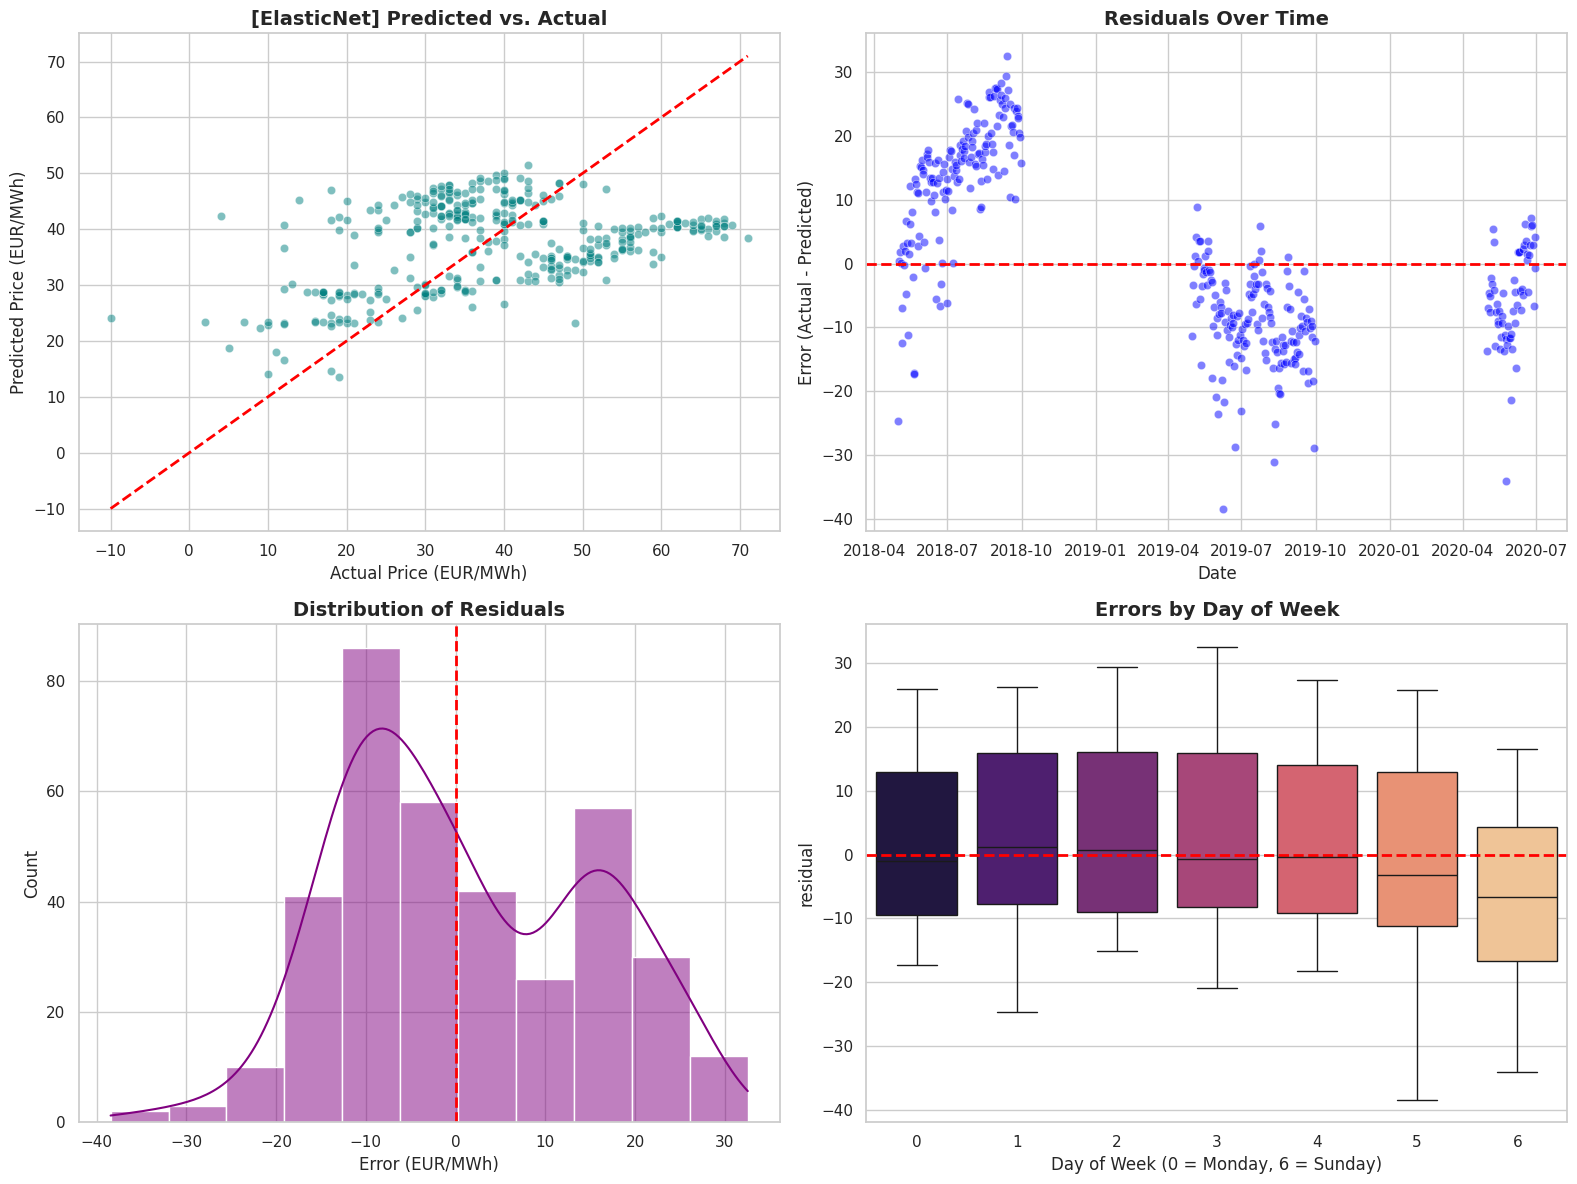

In [122]:
print("\n" + "="*50 + "\nFINAL MODEL LEADERBOARD (Average MAE)")
leaderboard = metrics_summary.groupby('model')['mae'].mean().reset_index().sort_values(by = 'mae')
print(leaderboard.to_string(index = False))

# prediction data creation
pred_df = prepare_prediction_data("/content/epex_fr_temp_pred.csv")
pred_df = engineer_calendar_features(pred_df)

# choosing the best model to use
# this was changes to choose xgboost
best_model_name = leaderboard.iloc[0]['model']
best_pipeline = trained_model[best_model_name]


# residual analysis
analyze_residuals_simple(results_df, best_model_name)


Forecasting

In [123]:
# forecasting
final_model, X_train_s, X_test_s, holdout_results = forecast_holdout(
    train_df=clean_df,
    pred_df=pred_df,
    target_col=CONFIG['target'],
    features=FINAL_MODEL_FEATURES,
    best_pipeline=best_pipeline,
    holdout_start='2020-07-01',
    holdout_end='2020-07-31',
    region_cols=REGION_COLS,
    calendar_features=CALENDAR_FEATURES,
    hdd_cdd_cols=HDD_CDD_COLS,
    HDD_CDD_COL_REF=HDD_CDD_COL_REF
)

print(holdout_results['predicted_price'].mean())

Generating final forecast for 2020-07-01 to 2020-07-31...
Final forecast complete.
28.9854727750767


In [124]:
X_train_s
X_test_s.columns

Index(['year', 'month', 'day_of_year', 'day_of_week', 'is_weekend',
       'is_holiday', 'is_lockdown', 'sin_day_of_year', 'cos_day_of_year',
       'is_school_end_july', 'is_bastille_bridge', 'is_grandes_vacances_july',
       'is_august_vacation', 'T_lisse_HDD', 'T_lisse_CDD', 'T_lisse',
       'Delta_T', 'Residual_Demand', 'Residual_Demand_sq',
       'Residual_Demand_cu', 'NUCLEAR AVAIL. (MW)', 'DEMAND (MW)'],
      dtype='object')

SHAP Interpretability

Generating SHAP values using 'both' methodology...

--- Calculating Model-Agnostic SHAP (EUR/MWh) ---


/tmp/ipykernel_8804/2141330168.py:31: FutureWarning:

The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.



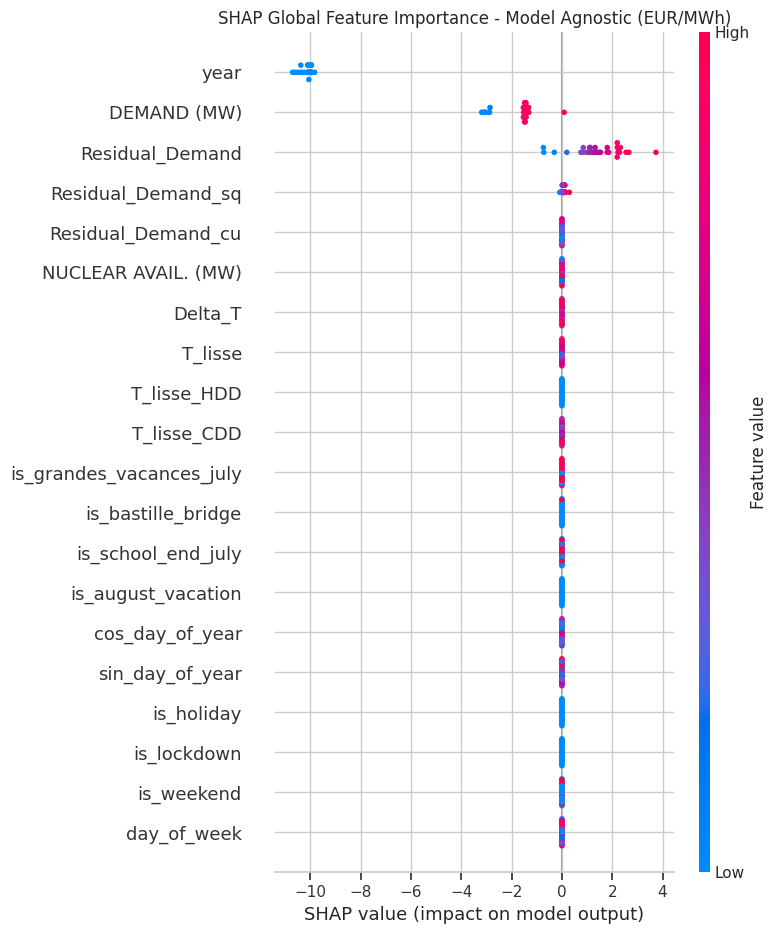

Waterfall Plot for July 1, 2020 (Model Agnostic):


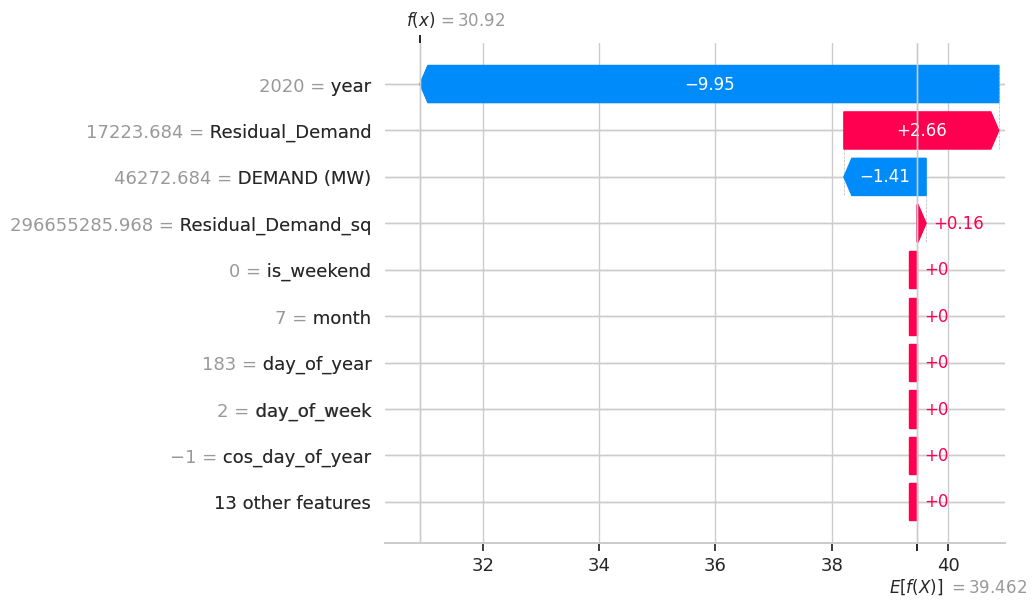


--- Calculating Model-Specific SHAP (Arcsinh Scale) ---
Detected Linear Model. Using LinearExplainer...


/tmp/ipykernel_8804/2141330168.py:74: FutureWarning:

The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.



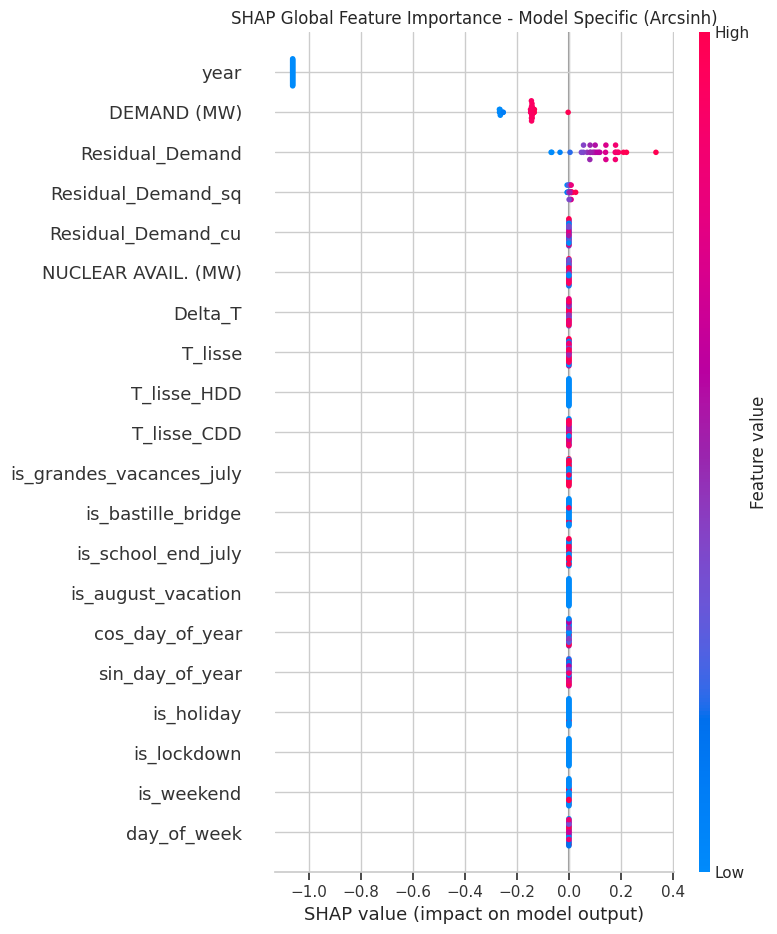

Waterfall Plot for July 1, 2020 (Model Specific):


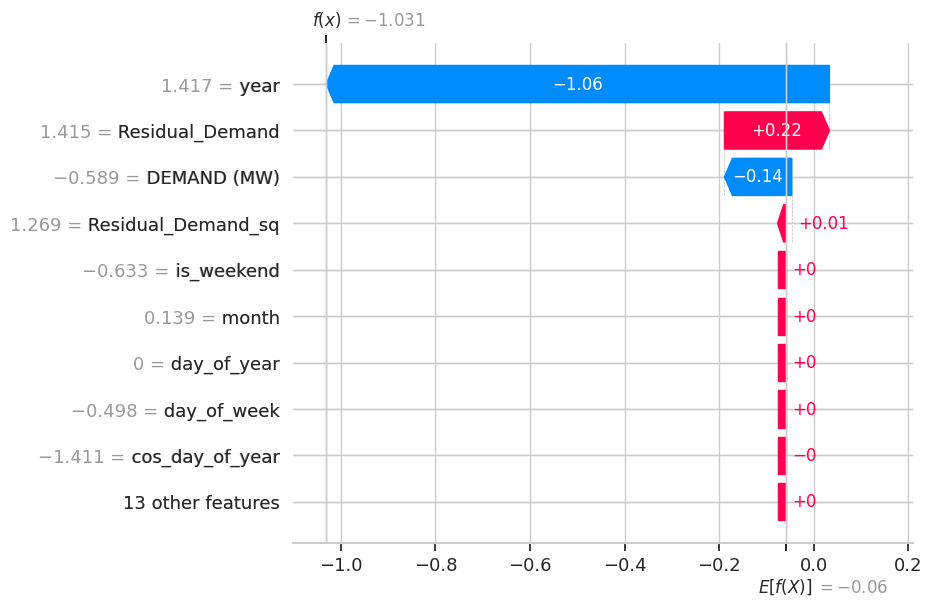

In [125]:
all_shap_vals = explain_predictions_shap(
    model=final_model,
    X_train_raw=X_train_s,
    X_test_raw=X_test_s,
    explainer_type='both'
)